# 1.0 Data Cleaning
### 1.1 Import file

In [1]:
# Import pandas and read csv file
import pandas as pd

nutrients = pd.read_csv("original_data/nutrients_csvfile.csv")

### 1.2 Display table

In [2]:
# Show all rows in the DataFrame
pd.set_option('display.max_rows', None)

# Show all columns too 
pd.set_option('display.max_columns', None)

# Display dataframe
nutrients

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,t,t,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,"Evaporated, undiluted",1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,"1,419","1,373",89,42,23,1.4,119,Dairy products
5,Powdered milk,1 cup,103,515,27,28,24,0,39,Dairy products
6,"skim, instant",1 1/3 cups,85,290,30,t,t,0,42,Dairy products
7,"skim, non-instant",2/3 cup,85,290,30,t,t,1,42,Dairy products
8,Goats' milk,1 cup,244,165,8,10,8,0,11,Dairy products
9,(1/2 cup ice cream),2 cups,540,690,24,24,22,0,70,Dairy products


### Raw Data Inspection
Here, I expand the DataFrame to display all rows and columns in order to manually inspect and identify potential issues such as missing values, duplicates, or unrealistic nutritional values that may appear in the middle of the dataset.


### 1.3 Remove / Replace Invalid Value

In [3]:
# Replace invalid string values ("t" and "t'") with 0 in nutrient columns only
num_cols = ['Calories','Protein','Fat','Sat.Fat','Fiber','Carbs']
nutrients[num_cols] = nutrients[num_cols].replace(["t", "t'"], 0)
nutrients.head()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,0,0,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,"Evaporated, undiluted",1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,"1,419","1,373",89,42,23,1.4,119,Dairy products


### Handling Invalid Values
In the dataset, some nutritional values were incorrectly recorded as 't' or "t'".
These were replaced with 0 so that the data can be processed numerically.

In [4]:
# Remove commas, the data will be treated as string if commas are not removed
nutrients = nutrients.replace(",", "", regex=True)

# Remove letter 'a' in Fiber column
nutrients['Fiber'] = nutrients['Fiber'].replace("a", "", regex=True)

# Safely update Calories at index 91
nutrients.loc[91, 'Calories'] = (8 + 44) / 2

nutrients.head()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,0,0,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,Evaporated undiluted,1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,1419,1373,89,42,23,1.4,119,Dairy products


### 1.4 Convert String into Integer

In [5]:
# Convert selected columns to numeric
num_cols = ['Grams', 'Calories', 'Protein', 'Fat', 'Sat.Fat', 'Fiber', 'Carbs']
nutrients[num_cols] = nutrients[num_cols].apply(pd.to_numeric, errors='coerce')


In [6]:
nutrients.dtypes

Food         object
Measure      object
Grams         int64
Calories    float64
Protein       int64
Fat           int64
Sat.Fat     float64
Fiber       float64
Carbs       float64
Category     object
dtype: object

### 1.5 Finding missing values

In [7]:
import pandas as pd

pd.set_option('display.width', 190)
pd.set_option('display.max_columns', None)

print(nutrients.isnull().any())
print('-'*120)
print(nutrients.describe())
print('-'*120)

# Count of missing values per column
print("Missing values per column:")
print(nutrients.isnull().sum())
print('-'*120)

# Quick look at the first few rows with missing values (if any)
print("Rows with missing values:")
print(nutrients[nutrients.isnull().any(axis=1)].head())
print('-'*120)

Food        False
Measure     False
Grams       False
Calories     True
Protein     False
Fat         False
Sat.Fat      True
Fiber        True
Carbs       False
Category    False
dtype: bool
------------------------------------------------------------------------------------------------------------------------
             Grams     Calories     Protein         Fat     Sat.Fat       Fiber       Carbs
count   335.000000   334.000000  335.000000  335.000000  333.000000  334.000000  335.000000
mean    143.211940   188.802395    8.573134    8.540299    6.438438    2.376078   24.982388
std     138.668626   184.453018   17.733722   19.797871   18.517656   16.078272   35.833106
min      11.000000     0.000000   -1.000000    0.000000    0.000000    0.000000    0.000000
25%      60.000000    75.000000    1.000000    0.000000    0.000000    0.000000    3.000000
50%     108.000000   131.000000    3.000000    1.000000    0.000000    0.200000   14.000000
75%     200.000000   250.000000   12.000000

### 1.6 Removing missing values

In [8]:
# Remove any rows that have one missing values
nutrients=nutrients.dropna()

# Returns a tuple (rows, columns) showing the dataset’s new size after removing rows with missing values.
nutrients.shape

# Fix impossible negative values
nutrients.loc[nutrients['Protein'] < 0, 'Protein'] = nutrients['Protein'].median()

# 2.0 EDA

### 2.1 Basic EDA - Quickly understand how the data looks like and whether it is clean enough to proceed

In [9]:
# Basic info about the dataset
print("Dataset Info:")
print(nutrients.info())
print("-"*80)

# Summary statistics for numeric columns
print("Summary Statistics:")
print(nutrients.describe().T)  # Transpose for better readability
print("-"*80)

# Count missing values per column
print("Missing Values per Column:")
print(nutrients.isnull().sum())
print("-"*80)

# Count of each food category
print("Food Category Counts:")
print(nutrients['Category'].value_counts())
print("-"*80)

# Extra: Check correlation between numeric nutrients
print("Correlation Between Nutrients:")
print(nutrients.corr(numeric_only=True))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 331 entries, 0 to 334
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Food      331 non-null    object 
 1   Measure   331 non-null    object 
 2   Grams     331 non-null    int64  
 3   Calories  331 non-null    float64
 4   Protein   331 non-null    int64  
 5   Fat       331 non-null    int64  
 6   Sat.Fat   331 non-null    float64
 7   Fiber     331 non-null    float64
 8   Carbs     331 non-null    float64
 9   Category  331 non-null    object 
dtypes: float64(4), int64(3), object(3)
memory usage: 28.4+ KB
None
--------------------------------------------------------------------------------
Summary Statistics:
          count        mean         std   min   25%    50%    75%     max
Grams     331.0  143.703927  139.368130  11.0  60.0  108.0  200.0  1419.0
Calories  331.0  188.622356  184.342696   0.0  75.0  130.0  250.0  1373.0
Protein   331.0    8.574018

### 2.2 Advance EDA - Identify relationships, pattern and trends that could affect modeling

### 2.2.1 Univariate analysis
- Distribution of Nutrients

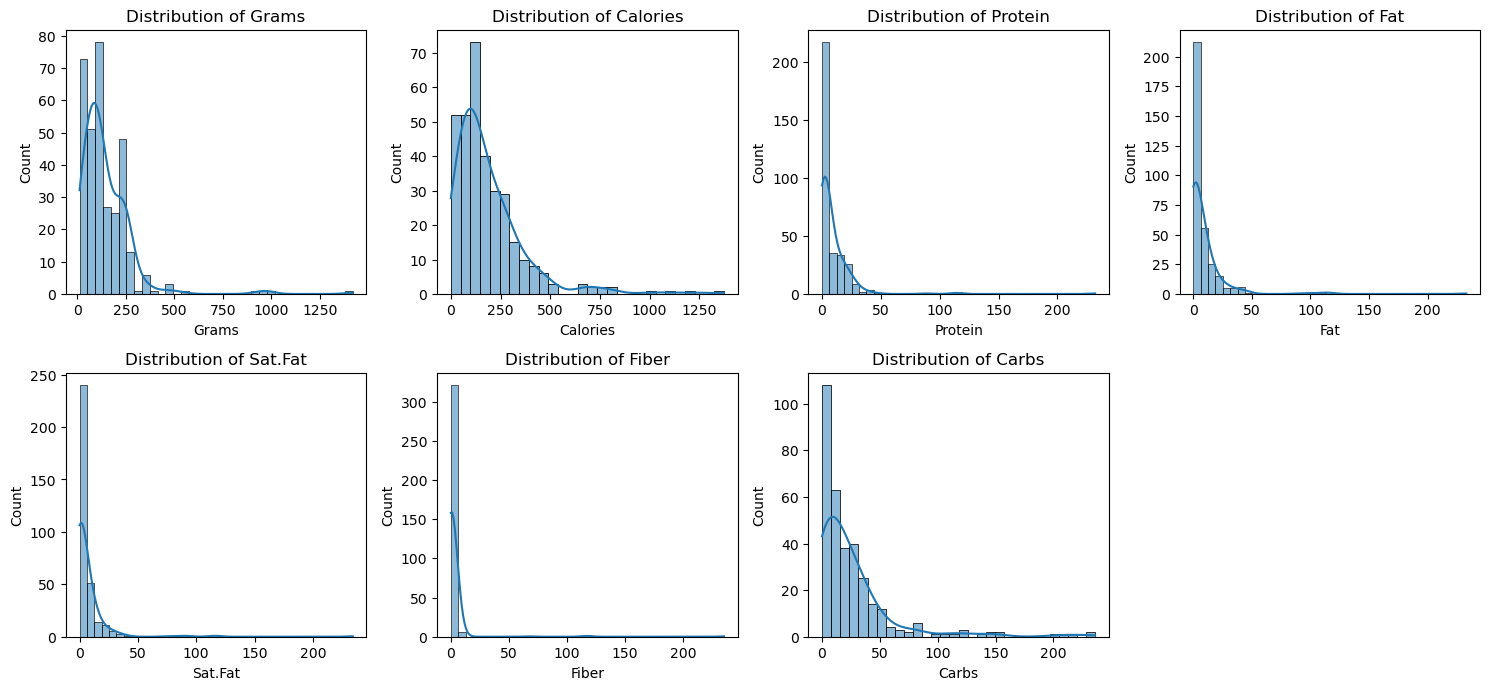

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution plots for each numeric column
# Ensures the histogram are only for numeric columns
numeric_cols = nutrients.select_dtypes(include=['float64', 'int64']).columns

# Loops over each numeric column.
# Creates a histogram (histplot) with a KDE curve (Kernel Density Estimate) showing the smoothed probability distribution.
# Arranges them into a grid layout (3 rows × 4 columns of charts).
# Uses tight_layout() to make sure plots don’t overlap.
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    sns.histplot(nutrients[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### From the plots: 

1. Distribution shape
   - Normal distribution → data is symmetrical; no transformation needed.
   - Skewed distribution → may need transformation (log, sqrt) for some ML algorithms.
2. Outliers
   - Extreme values at the far ends of the histogram could affect clustering results.
3. Data spread
   - Whether values are tightly clustered or widely spread out.
4. Potential scaling needs
   - If one variable spans a huge range (e.g., Calories from 0 to 5000) while others are 0–10, scaling will be important before clustering.

- Boxplots for nutrients by category

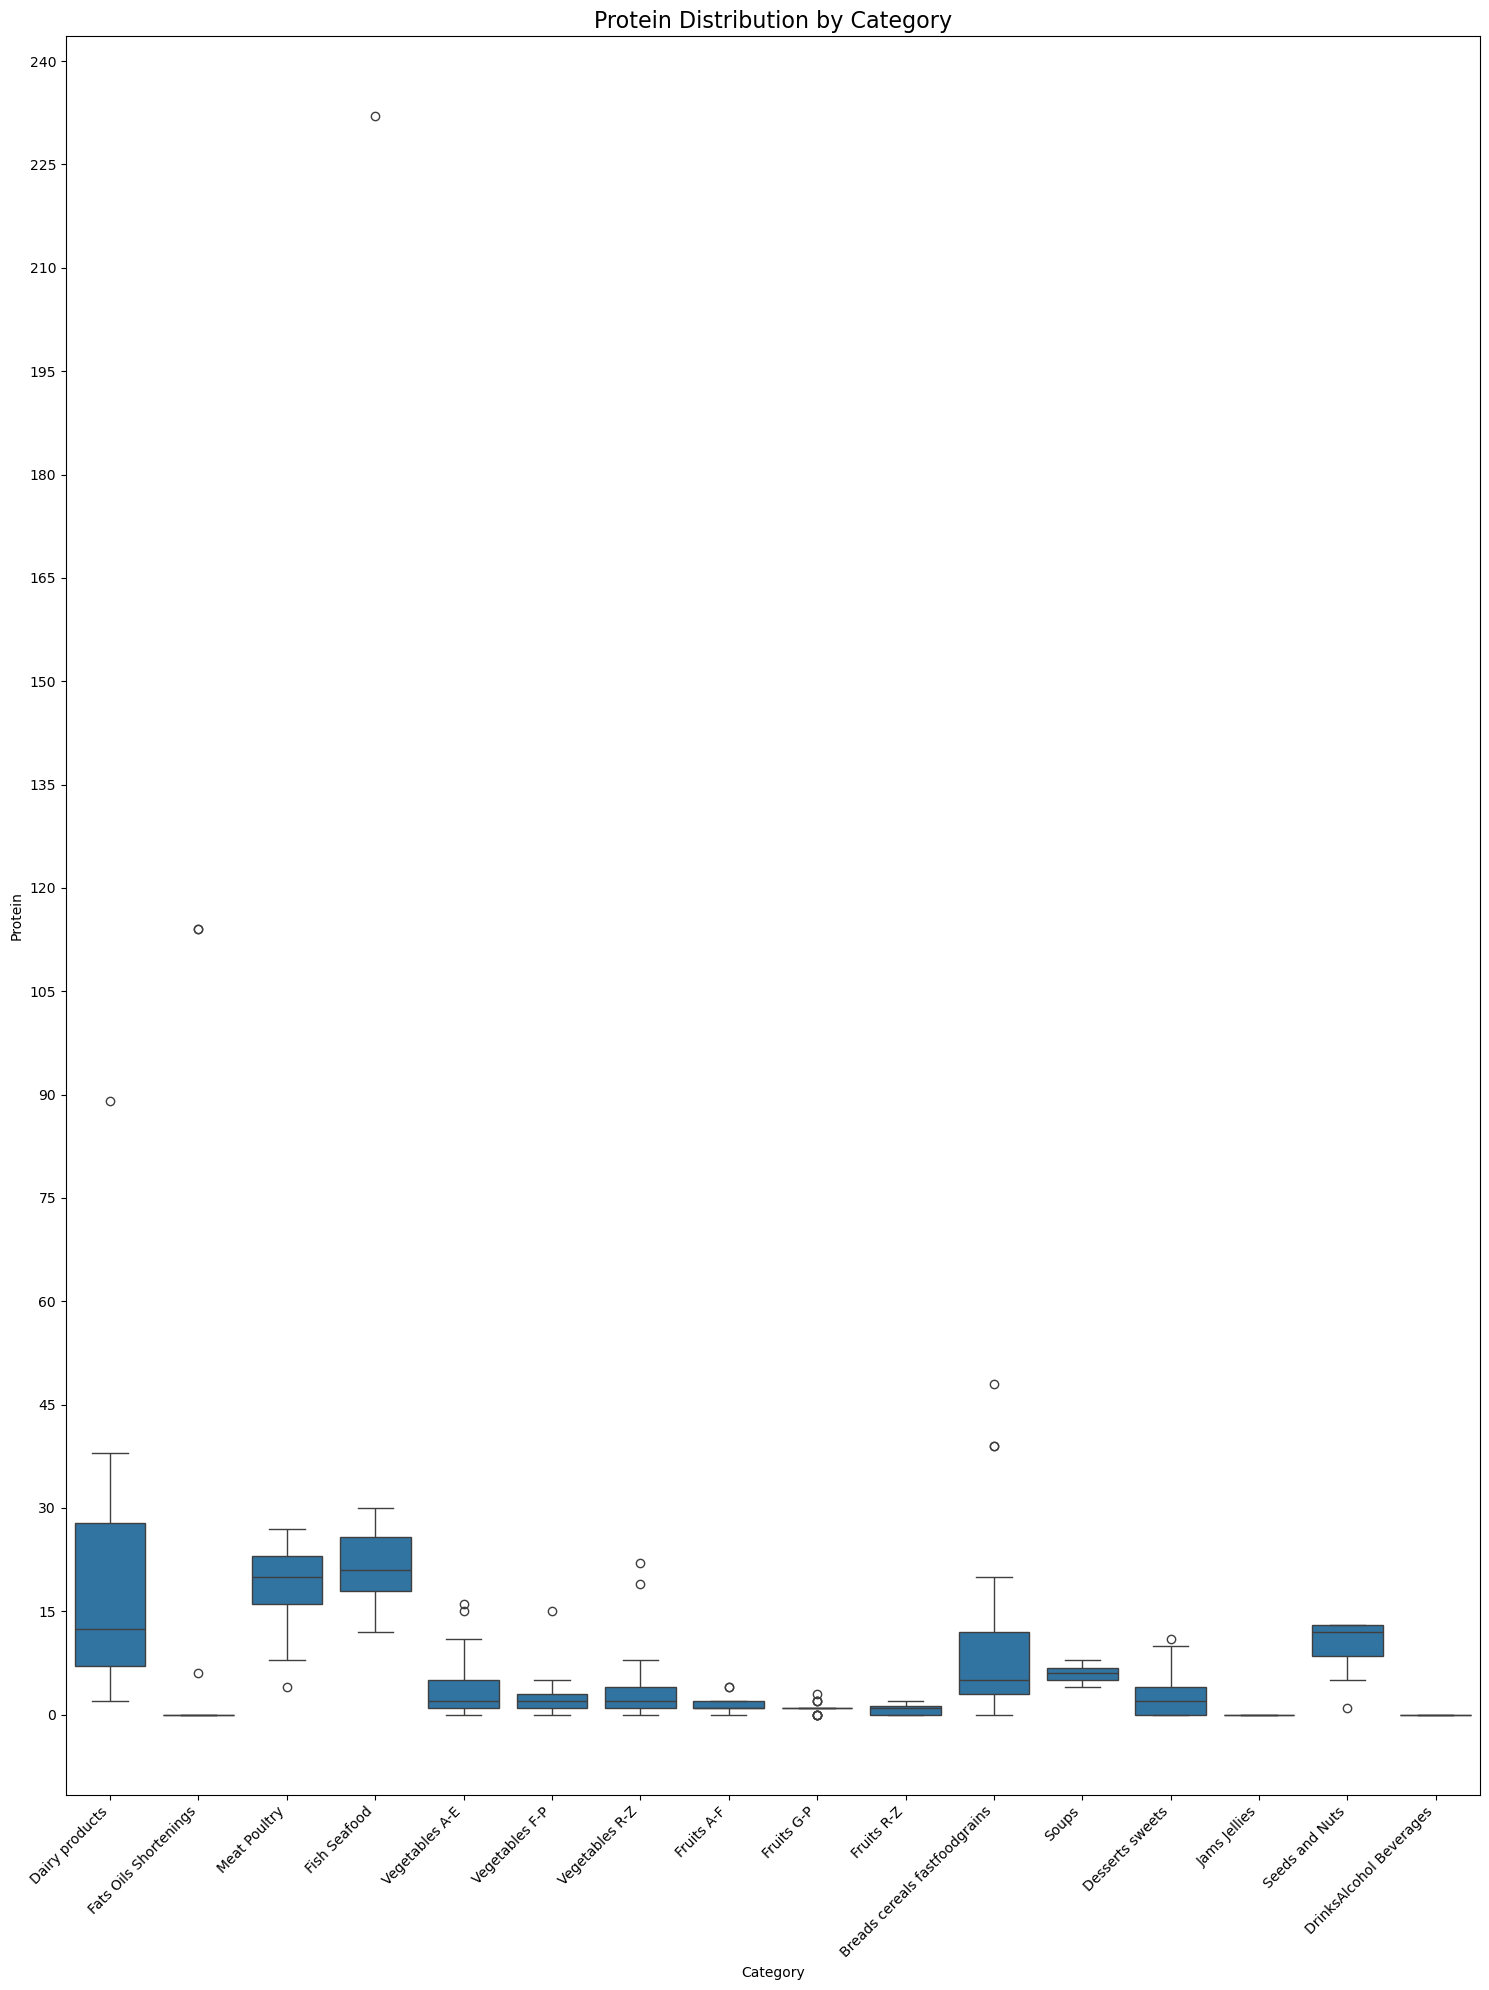

In [11]:
# Boxplots by Category (example: Protein by Category)
# Setting figure size
plt.figure(figsize=(15, 20)) 
sns.boxplot(data=nutrients, x='Category', y='Protein')
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0, int(nutrients['Protein'].max()) + 15, 15))
plt.title('Protein Distribution by Category', fontsize=16)
plt.tight_layout()
plt.show()

### From the plot: 

1. Median Protein per Category:
   - The line inside each box shows the typical protein content of that category.
2. Spread of Protein Values:
   - The size of the box (IQR) shows how variable protein content is within a category.
   - Taller boxes → more variability; shorter boxes → more consistency.
3. Outliers:
   - The white circles outside the whiskers are outliers, indicating unusually high or low protein values.
4. Comparison Across Categories:
   - You can see which categories are generally higher or lower in protein.
   - E.g., “Meat” might have higher median protein than “Vegetables”.
5. Symmetry and Skewness:
   - If the median is closer to the bottom or top of the box, the data is skewed.
   - Longer whiskers on one side also indicate skewness.

### 2.2.2 Bivariate & Multivariate Analysis
- KDE Plots: Nutrient Relationships

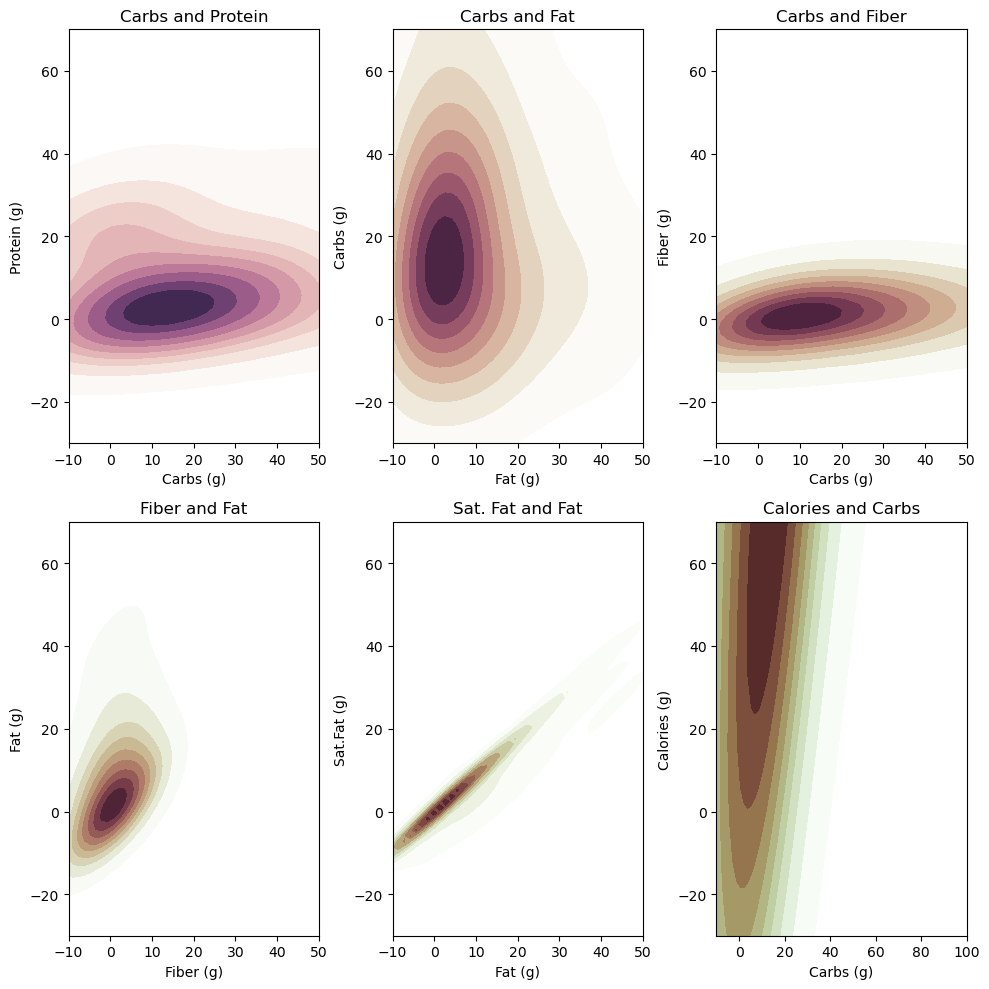

In [12]:
# KDE Plots

import matplotlib.pyplot as plt
import seaborn as sns

# Define plots as tuples: (x_col, y_col, title, xlim, ylim, cmap_start)
plots = [
    ('Carbs',    'Protein',   'Carbs and Protein',  (-10, 50), (-30, 70), 0.00),
    ('Fat',      'Carbs',     'Carbs and Fat',      (-10, 50), (-30, 70), 0.25),
    ('Carbs',    'Fiber',     'Carbs and Fiber',    (-10, 50), (-30, 70), 0.33),
    ('Fiber',    'Fat',       'Fiber and Fat',      (-10, 50), (-30, 70), 0.45),
    ('Fat',      'Sat.Fat',   'Sat. Fat and Fat',   (-10, 50), (-30, 70), 0.56),
    ('Carbs',    'Calories',  'Calories and Carbs', (-10, 100), (-30, 70), 0.68),
]

# Creating subplot grids
f, axes = plt.subplots(2, 3, figsize=(10, 10), sharex=False, sharey=False)

# Looping through configuration
for ax, (x_col, y_col, title, xlim, ylim, cmap_start) in zip(axes.flat, plots):
    # Setting color map
    cmap = sns.cubehelix_palette(start=cmap_start, light=1, as_cmap=True)
    # Drawing kde plot
    sns.kdeplot(
        x=nutrients[x_col], 
        y=nutrients[y_col], 
        cmap=cmap, 
        fill=True, 
        ax=ax
    )
    # Customize the plot
    ax.set(
        xlim=xlim, 
        ylim=ylim, 
        title=title, 
        xlabel=f"{x_col} (g)", 
        ylabel=f"{y_col} (g)"
    )

f.tight_layout()
plt.show()


- Correlation Check

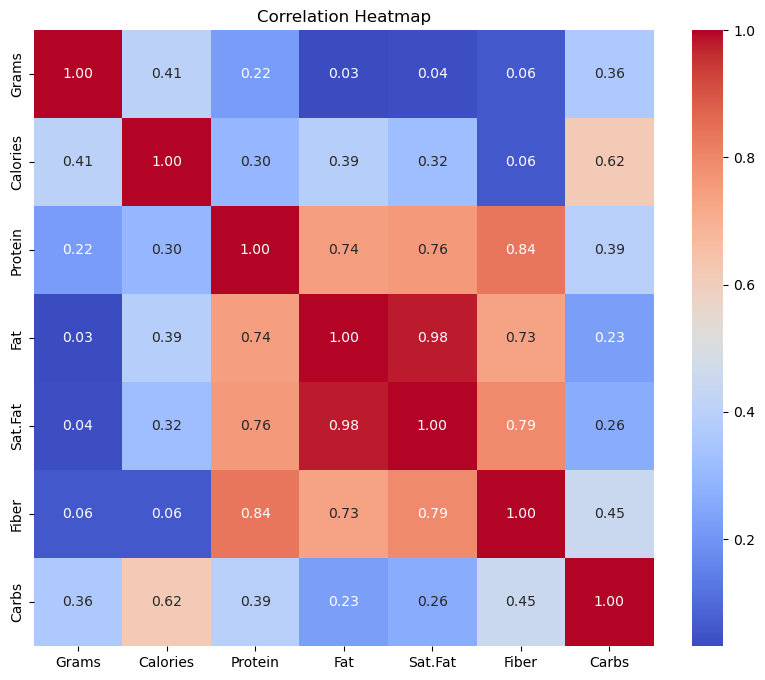

In [13]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = nutrients[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### From the plot:
- Quick overview of how all numeric variables relate to each other.

1. Strong positive relationships → e.g., if Calories and Fat have 0.92, foods with more fat also have more calories.

2. Strong negative relationships → e.g., if Protein and Sugar have -0.65, high protein foods tend to have less sugar.

3. Redundancy in data → If two columns are very correlated (e.g., 0.99), you might remove one to simplify models.

4. Potential features for prediction → Variables with strong correlation to your target are good candidates.

In [14]:
# Check highly correlated features (> 0.9)
high_corr = []
threshold = 0.9
for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and abs(corr_matrix.loc[i, j]) > threshold:
            high_corr.append((i, j, corr_matrix.loc[i, j]))

print("Highly correlated feature pairs (>0.9):")
for pair in high_corr:
    print(pair)

Highly correlated feature pairs (>0.9):
('Fat', 'Sat.Fat', np.float64(0.9781668973481307))
('Sat.Fat', 'Fat', np.float64(0.9781668973481307))


### 2.2.3 Category-Specific Insights
- Top 10 Protein-Rich Foods (Interactive)

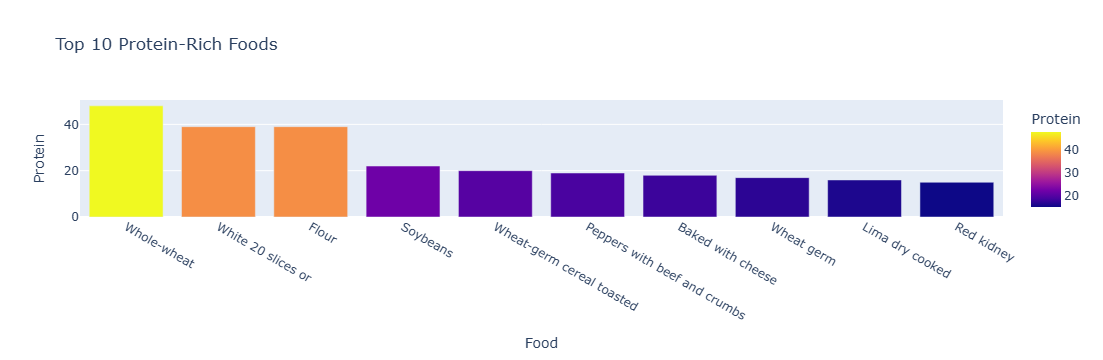

In [15]:
import plotly.express as px

# Select categories
alls = [
    'Vegetables A-E',
    'Vegetables F-P',
    'Vegetables R-Z',
    'Breads cereals fastfoodgrains',
    'Seeds and Nuts'
]

# Filter datasets with defined category
prot = nutrients[nutrients['Category'].isin(alls)]

# Sort by protein
protein_rich = prot.sort_values(by='Protein', ascending=False)

# Select the top 10
top_10 = protein_rich.head(10)  

# Creating interactive bar chart
fig = px.bar(
    top_10, 
    x='Food', 
    y='Protein', 
    color='Protein', 
    title='Top 10 Protein-Rich Foods'
)
fig.show()


- Top 10 Foods by Fat Content

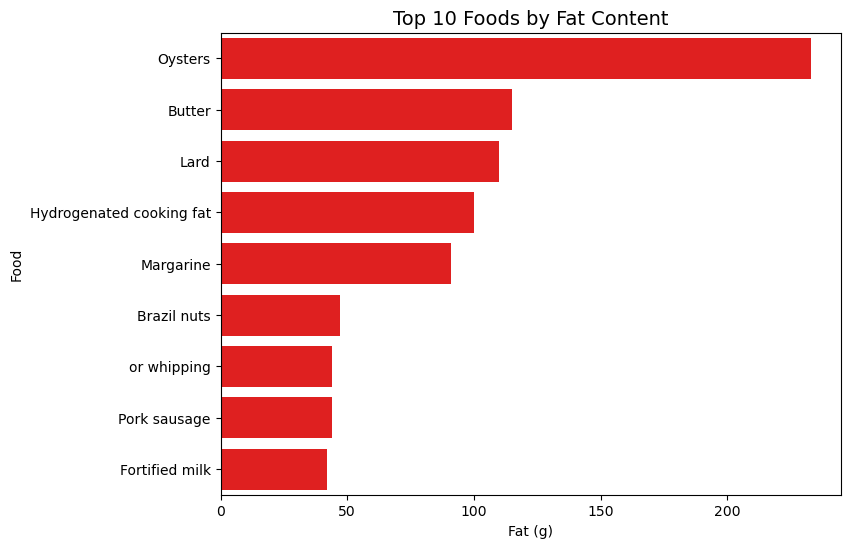

In [16]:
# Top 10 Foods by Fat Content
top_fat = nutrients.sort_values(by='Fat', ascending=False).head(10)
plt.figure(figsize=(8,6))
sns.barplot(data=top_fat, x='Fat', y='Food', color='red')  # simple red bars
plt.title('Top 10 Foods by Fat Content', fontsize=14)
plt.xlabel('Fat (g)')
plt.ylabel('Food')
plt.show()

### 2.2.4 Outlier detection

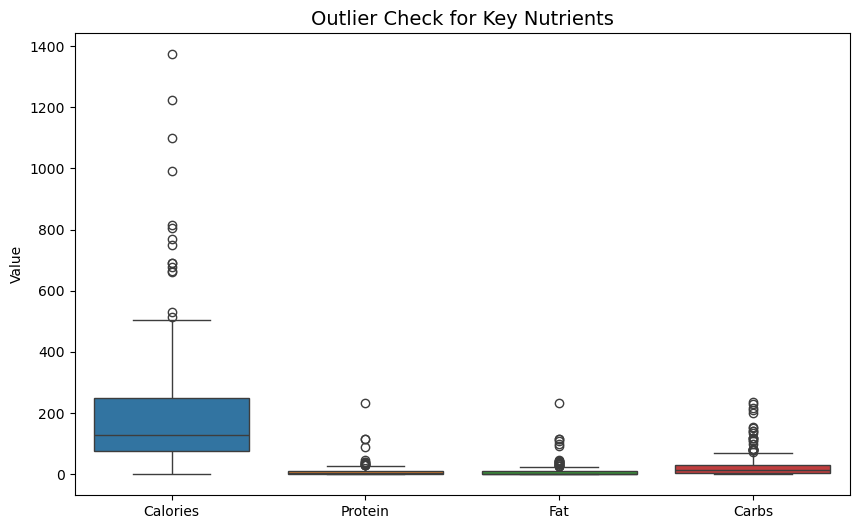

In [17]:
# Outlier Check for Key Nutrients
plt.figure(figsize=(10,6))
sns.boxplot(data=nutrients[['Calories','Protein','Fat','Carbs']])
plt.title('Outlier Check for Key Nutrients', fontsize=14)
plt.ylabel('Value')
plt.show()

# 3.0 Data Preprocessing

In [18]:
# Table before processes
nutrients

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660.0,32,40,36.0,0.00,48.0,Dairy products
1,Milk skim,1 qt.,984,360.0,36,0,0.0,0.00,52.0,Dairy products
2,Buttermilk,1 cup,246,127.0,9,5,4.0,0.00,13.0,Dairy products
3,Evaporated undiluted,1 cup,252,345.0,16,20,18.0,0.00,24.0,Dairy products
4,Fortified milk,6 cups,1419,1373.0,89,42,23.0,1.40,119.0,Dairy products
5,Powdered milk,1 cup,103,515.0,27,28,24.0,0.00,39.0,Dairy products
6,skim instant,1 1/3 cups,85,290.0,30,0,0.0,0.00,42.0,Dairy products
7,skim non-instant,2/3 cup,85,290.0,30,0,0.0,1.00,42.0,Dairy products
8,Goats' milk,1 cup,244,165.0,8,10,8.0,0.00,11.0,Dairy products
9,(1/2 cup ice cream),2 cups,540,690.0,24,24,22.0,0.00,70.0,Dairy products


### 3.1 Removing non-numeric features

In [19]:
# Step 1: Keep only numeric nutrient features
numeric_cols = nutrients.select_dtypes(include=['float64', 'int64']).columns

# Drop 'Sat.Fat' (correlated with Fat) and 'Grams' (serving size, not a nutrient)
features = nutrients[numeric_cols].drop(columns=['Sat.Fat', 'Grams'])


### 3.2 Standard Scaling

In [20]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standard Scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Convert back to DataFrame for convenience
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)

print("Scaled dataset (with outliers):", scaled_df.shape)
scaled_df.head()

Scaled dataset (with outliers): (331, 5)


,Calories,Protein,Fat,Fiber,Carbs
0,2.560944,1.316324,1.600593,-0.148346,0.633649
1,0.931076,1.541088,-0.428695,-0.148346,0.745039
2,-0.334788,0.023936,-0.175034,-0.148346,-0.341008
3,0.849583,0.417272,0.585949,-0.148346,-0.034687
4,6.434596,4.519199,1.702057,-0.061528,2.610811


We apply `StandardScaler` to normalize the dataset so that each feature has a mean of 0 and a standard deviation of 1.  
This ensures that features with larger ranges (e.g., Calories) do not dominate clustering results.

### 3.3 Apply Feature Weighting

In [21]:
# Apply Feature Weighting (same as in app.py)
weight_map = {'Calories': 1.5, 'Protein': 2.5, 'Fat': 2.0, 'Fiber': 2.0, 'Carbs': 1.0}

for col in scaled_df.columns:
    if col in weight_map:
        scaled_df[col] *= weight_map[col]

print("After weighting applied:")
scaled_df.head()

After weighting applied:


,Calories,Protein,Fat,Fiber,Carbs
0,3.841416,3.290811,3.201185,-0.296691,0.633649
1,1.396614,3.852719,-0.857389,-0.296691,0.745039
2,-0.502181,0.059841,-0.350067,-0.296691,-0.341008
3,1.274374,1.043179,1.171898,-0.296691,-0.034687
4,9.651894,11.297998,3.404114,-0.123055,2.610811


To emphasize the importance of some nutrients over others, we assign weights:  
- **Protein** and **Fiber** are given higher weights (2.5 and 2.0).  
- **Calories** and **Fat** are moderately weighted (1.5 and 2.0).  
- **Carbs** are given the lowest weight (1.0).  

This step helps the clustering algorithm prioritize more nutritionally significant features.

### 3.4 Clipping

In [22]:
# Clipping values to reduce outlier effects
scaled_df = scaled_df.clip(-3, 3)

print("After clipping [-3, 3]:")
scaled_df.head()

After clipping [-3, 3]:


,Calories,Protein,Fat,Fiber,Carbs
0,3.000000,3.000000,3.000000,-0.296691,0.633649
1,1.396614,3.000000,-0.857389,-0.296691,0.745039
2,-0.502181,0.059841,-0.350067,-0.296691,-0.341008
3,1.274374,1.043179,1.171898,-0.296691,-0.034687
4,3.000000,3.000000,3.000000,-0.123055,2.610811


To reduce the influence of extreme outliers, we clip all values within the range **[-3, 3]**.  
This prevents extreme scaled values from skewing clustering results while retaining useful variation.

### 3.5 Outlier Removal

In [23]:
# Function to remove outliers using IQR
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Apply outlier removal
scaled_df_clean = remove_outliers_iqr(scaled_df, scaled_df.columns)

print("Scaled dataset shape (with outliers):", scaled_df.shape)
print("Scaled dataset shape (after outlier removal):", scaled_df_clean.shape)
scaled_df_clean.head()

Scaled dataset shape (with outliers): (331, 5)
Scaled dataset shape (after outlier removal): (257, 5)


,Calories,Protein,Fat,Fiber,Carbs
2,-0.502181,0.059841,-0.350067,-0.296691,-0.341008
3,1.274374,1.043179,1.171898,-0.296691,-0.034687
8,-0.192507,-0.080636,0.157254,-0.296691,-0.396703
10,0.377947,-0.080636,0.258719,-0.296691,0.021007
11,-0.494032,1.324133,-0.451532,-0.172666,-0.341008


### 3.6 Visualizing outlier removal effect using boxplot

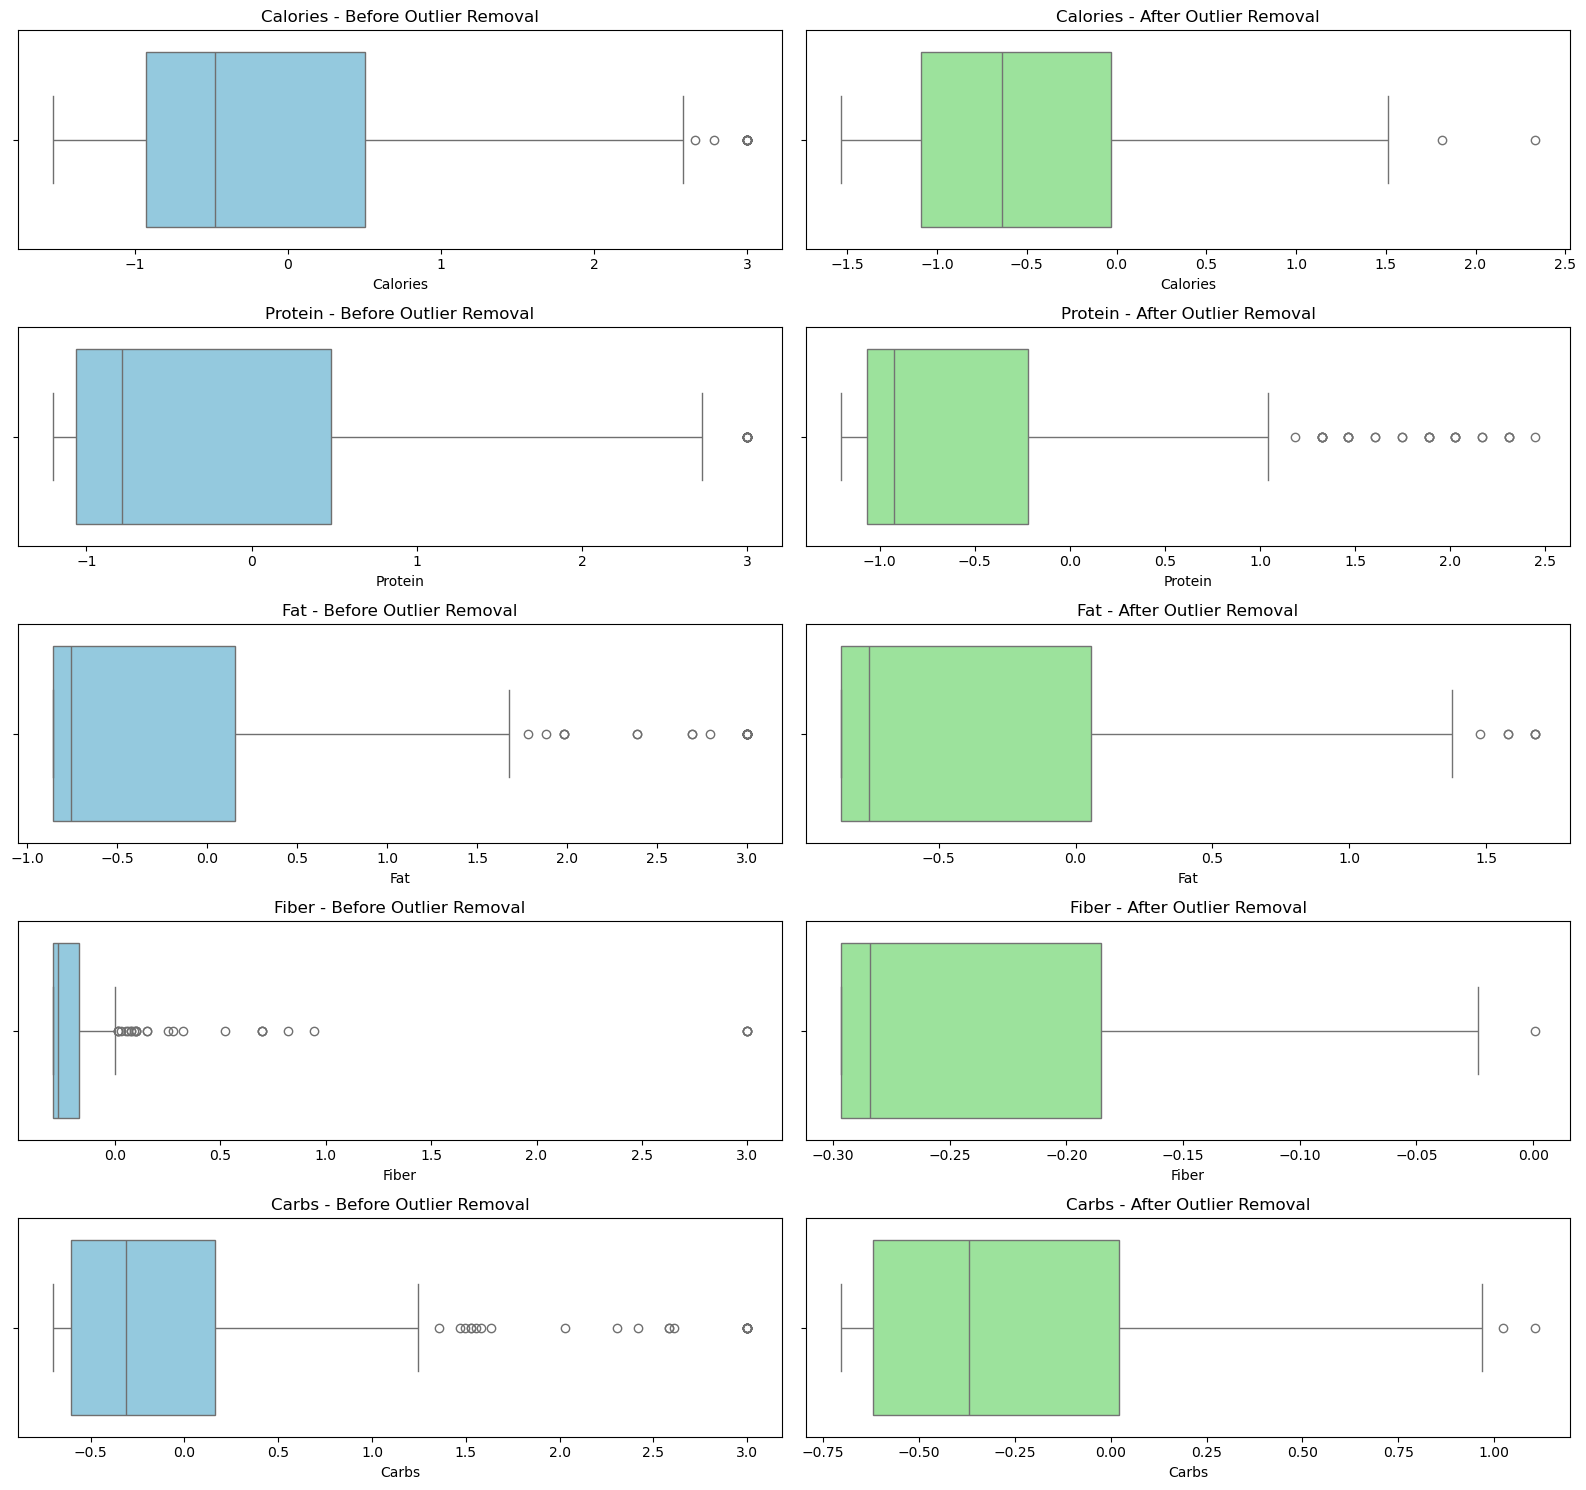

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compare distributions before and after outlier removal (scaled)
plt.figure(figsize=(16, len(scaled_df.columns) * 3))

for i, col in enumerate(scaled_df.columns, 1):
    # Before outlier removal
    plt.subplot(len(scaled_df.columns), 2, 2*i - 1)
    sns.boxplot(x=scaled_df[col], color="skyblue")
    plt.title(f"{col} - Before Outlier Removal")

    # After outlier removal
    plt.subplot(len(scaled_df_clean.columns), 2, 2*i)
    sns.boxplot(x=scaled_df_clean[col], color="lightgreen")
    plt.title(f"{col} - After Outlier Removal")

plt.tight_layout()
plt.show()


### 3.7 Exporting preprocessed data

In [25]:
scaled_df.to_csv("preprocessed_data/scaled_df.csv", index=False)
scaled_df_clean.to_csv("preprocessed_data/scaled_df_clean.csv", index=False)


Two different datasets, scaled datasets with or without outliers will be used later to determine which has better performance for the clustering algorithm

# 4.0 Applying Machine Learning Algorithm

### Comparative Evaluation of Clustering Algorithms (K-Means, Hierarchical, DBSCAN)  


In [26]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

In [27]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

datasets = {
    "With Outliers": scaled_df,
    "Without Outliers": scaled_df_clean
}

results = []

for ds_name, X in datasets.items():
    # --- KMeans & Hierarchical: test multiple k values ---
    for k in range(2, 11):  # k = 2 to 10
        # KMeans
        labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
        sil = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)
        results.append([ds_name, "KMeans", k, sil, ch, db])
        
        # Hierarchical
        labels = AgglomerativeClustering(n_clusters=k, linkage='average').fit_predict(X)
        sil = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)
        results.append([ds_name, "Hierarchical", k, sil, ch, db])
    
    # --- DBSCAN (no k) ---
    labels = DBSCAN(eps=0.3, min_samples=5).fit_predict(X)
    if len(set(labels)) > 1 and len(set(labels)) < len(X):
        sil = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)
    else:
        sil, ch, db = None, None, None
    
    results.append([ds_name, "DBSCAN", None, sil, ch, db])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Dataset", "Algorithm", "k", 
                                            "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])

# Round metrics for readability
results_df[["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]] = results_df[
    ["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]
].round(3)

# Sort for clarity
results_df = results_df.sort_values(by=["Dataset", "Algorithm", "k"]).reset_index(drop=True)

# Display separately by dataset for clarity
for ds in results_df["Dataset"].unique():
    print(f"\n===== Results for {ds} =====")
    display(results_df[results_df["Dataset"] == ds].drop(columns=["Dataset"]))



===== Results for With Outliers =====


,Algorithm,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,DBSCAN,NaN,0.001,36.683,2.209
1,Hierarchical,2.0,0.607,39.873,0.675
2,Hierarchical,3.0,0.511,76.607,0.792
3,Hierarchical,4.0,0.500,82.690,0.733
4,Hierarchical,5.0,0.500,65.491,0.609
5,Hierarchical,6.0,0.484,57.805,0.640
6,Hierarchical,7.0,0.481,126.219,0.693
7,Hierarchical,8.0,0.475,109.911,0.639
8,Hierarchical,9.0,0.455,100.933,0.636
9,Hierarchical,10.0,0.440,143.922,0.709



===== Results for Without Outliers =====


,Algorithm,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
19,DBSCAN,NaN,0.128,50.666,1.578
20,Hierarchical,2.0,0.528,7.930,0.315
21,Hierarchical,3.0,0.500,111.696,0.645
22,Hierarchical,4.0,0.475,145.304,0.757
23,Hierarchical,5.0,0.449,113.839,0.716
24,Hierarchical,6.0,0.462,108.284,0.784
25,Hierarchical,7.0,0.451,102.415,0.727
26,Hierarchical,8.0,0.349,115.942,0.837
27,Hierarchical,9.0,0.376,138.428,0.825
28,Hierarchical,10.0,0.376,130.650,0.801


K-Means, Hierarchical Clustering, and DBSCAN were applied to both datasets (with and without outliers).  
The clustering quality was assessed using three key metrics:  

- **Silhouette Score** – evaluates cohesion and separation of clusters (higher = better).  
- **Calinski-Harabasz Index** – measures variance ratio between clusters (higher = better).  
- **Davies-Bouldin Index** – evaluates similarity between clusters (lower = better).  

The results provide an overview of how each algorithm performs under varying cluster sizes (k = 2 to 10 for K-Means and Hierarchical) and for DBSCAN, which determines clusters based on density without requiring k.  
These findings form the basis for selecting the most suitable clustering method and parameters for the dataset.  

### Choice of k=3 for KMeans

From the evaluation metrics, we observed that:
- **With outliers:** K=4 gave the best silhouette score.  
- **Without outliers:** K=2 gave the best silhouette score.  

However, in the final application we fixed **k=3** for KMeans. This choice is justified by the following reasons:

1. **Interpretability vs Metrics**  
   While k=2 or k=4 yielded slightly better quantitative scores, these options either oversimplified the clusters (k=2) or produced more fragmented groups (k=4). By choosing k=3, we balance clustering quality with meaningful separation.

2. **Domain-driven categories**  
   The project objective was to classify foods into **three intuitive nutrition categories**:  
   - Balanced Nutrition  
   - High-Energy Dense  
   - Protein & Fiber Rich  
   Fixing k=3 ensures the clustering aligns with this nutritional interpretation.

3. **Consistency in Application**  
   Using k=3 across datasets (with/without outliers) allows consistent labeling and communication of results in the web application, making the system more practical for end users.

👉 **Conclusion:** Even though k=2 or k=4 performed better on some metrics, **k=3 provides the best trade-off between statistical performance and practical interpretability.**

### 4.1 K-Means Clustering (Ting Rong You)

### 4.1.1 Cluster Size Distribution for K-Means (k=3, With Outliers)


In [28]:
from sklearn.cluster import KMeans
import pandas as pd

# ======================
# Cluster Size for k=3 (With Outliers only)
# ======================

km = KMeans(n_clusters=3, random_state=42)
labels = km.fit_predict(scaled_df)

# Get cluster sizes
sizes = pd.Series(labels).value_counts().sort_index().tolist()

print("===== With Outliers =====")
print(f"Cluster Sizes for k=3: {sizes}")


===== With Outliers =====
Cluster Sizes for k=3: [197, 37, 97]


K-Means clustering was applied with **k = 3** on the dataset containing outliers.  
The resulting cluster sizes show a significant imbalance, with one dominant cluster containing the majority of food items, and two much smaller clusters.  
This suggests that the presence of outliers may heavily influence cluster assignments, causing disproportionate grouping and reducing clustering effectiveness.  

### 4.1.2 K-Means Clustering with Elbow Method and Cluster Assignment (With Outliers)


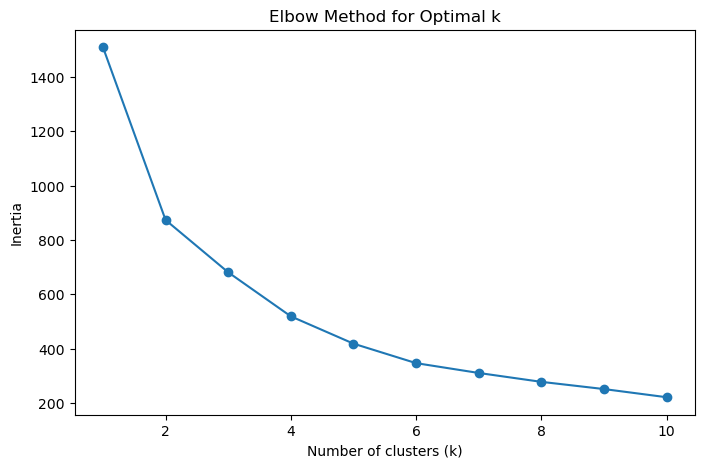

Clustered Features (Scaled):
   Calories   Protein       Fat     Fiber     Carbs  Cluster
0  3.000000  3.000000  3.000000 -0.296691  0.633649        2
1  1.396614  3.000000 -0.857389 -0.296691  0.745039        2
2 -0.502181  0.059841 -0.350067 -0.296691 -0.341008        0
3  1.274374  1.043179  1.171898 -0.296691 -0.034687        2
4  3.000000  3.000000  3.000000 -0.123055  2.610811        2


In [29]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# =============================
# Step 0: Prepare features
# =============================
features = scaled_df.copy()  # already scaled and preprocessed

# =============================
# Step 1: Elbow Method to find optimal k
# =============================
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=50, max_iter=500, random_state=42)
    km.fit(features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

# =============================
# Step 2: Fit KMeans with chosen k
# =============================
optimal_k = 3  # adjust based on elbow
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=50, max_iter=500, random_state=42)
labels = kmeans.fit_predict(features)

# =============================
# Step 3: Assign clusters to dataset
# =============================
features['Cluster'] = labels

# =============================
# Step 4: Preview results
# =============================
print("Clustered Features (Scaled):")
print(features.head())

The K-Means algorithm was applied to the scaled dataset containing outliers.  
- **Step 1:** The **Elbow Method** was used to determine the optimal number of clusters, where inertia was plotted across values of *k* from 1 to 10.  
- **Step 2:** Based on the elbow curve, **k = 3** was selected as the optimal cluster count.  
- **Step 3:** Cluster labels were generated and assigned to both the scaled nutrient features and the original dataset for interpretability.  
- **Step 4:** The clustered datasets were previewed to confirm successful integration of cluster assignments.  

This process establishes the foundation for analyzing cluster characteristics, distributions, and nutrient patterns.  

### 4.1.3 PCA Visualization of K-Means Clusters (k=3, With Outliers)


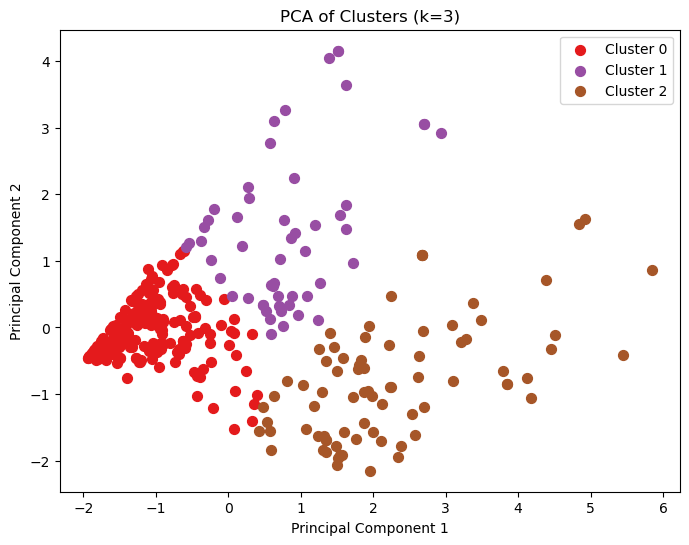

In [30]:
from sklearn.decomposition import PCA

# Fit PCA on scaled dataset (excluding cluster column)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_df)

# Create PCA DataFrame
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels  # use KMeans cluster labels


import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA dataframe already prepared
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels  # use labels from previous cell

plt.figure(figsize=(8, 6))
unique_clusters = sorted(pca_df['Cluster'].unique())
colors = plt.colormaps['Set1']  # updated colormap access

for cluster_id in unique_clusters:
    cluster_points = pca_df[pca_df['Cluster'] == cluster_id]
    plt.scatter(
        cluster_points['PC1'], cluster_points['PC2'],
        color=colors(cluster_id / len(unique_clusters)),  # normalize 0–1
        label=f"Cluster {cluster_id}", s=50
    )

plt.title("PCA of Clusters (k=3)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


Principal Component Analysis (PCA) was applied to reduce the multidimensional nutrient dataset into two dimensions for visualization.  
The resulting scatter plot displays the three clusters identified by K-Means (k=3), with each cluster distinguished by color.  

This visualization highlights how food items are grouped in reduced dimensional space, allowing for a clearer comparison of inter-cluster separation and intra-cluster compactness.  

### 4.1.4 Cluster Profiles and Sizes for K-Means (k=3, With Outliers)


Cluster Profiles (average nutrient values per cluster):
         Calories   Protein       Fat     Fiber     Carbs
Cluster                                                  
0       -0.807333 -0.844831 -0.639241 -0.197031 -0.282807
1        1.106275 -0.377493 -0.279234 -0.173836  1.059677
2        0.903057  1.554691  1.094117 -0.060688 -0.167059


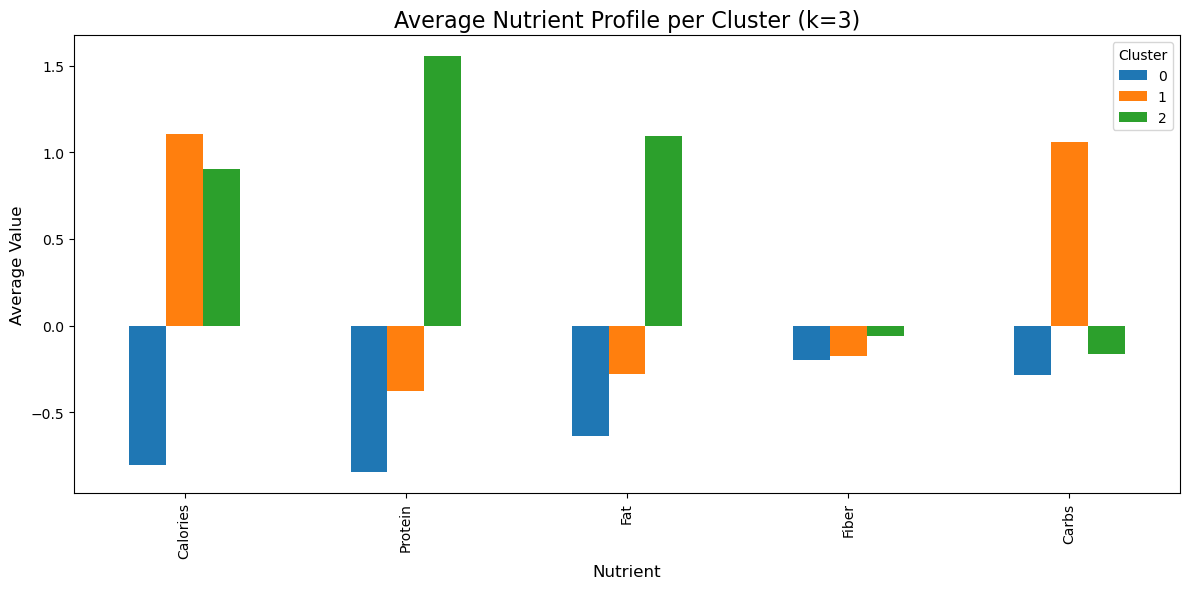


Cluster Sizes:
Cluster
0    200
1     53
2     78
Name: count, dtype: int64


In [31]:
import matplotlib.pyplot as plt

# Use the clustered dataset
clustered_data = features.copy()  # features already contains the 'Cluster' column

# =============================
# 1. Compute cluster profiles (average nutrient values per cluster)
# =============================
cluster_profiles = clustered_data.groupby('Cluster').mean(numeric_only=True)

print("Cluster Profiles (average nutrient values per cluster):")
print(cluster_profiles)

# =============================
# 2. Plot cluster profiles for easier visualization
# =============================
cluster_profiles.T.plot(kind='bar', figsize=(12,6))
plt.title("Average Nutrient Profile per Cluster (k=3)", fontsize=16)
plt.ylabel("Average Value", fontsize=12)
plt.xlabel("Nutrient", fontsize=12)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# =============================
# 3. Check cluster sizes
# =============================
cluster_sizes = clustered_data['Cluster'].value_counts().sort_index()
print("\nCluster Sizes:")
print(cluster_sizes)


The table below shows the **average nutrient profile** for each of the three clusters, expressed in standardized values (z-scores):

- **Negative values** indicate that the cluster’s average is **below the dataset mean** for that nutrient.  
- **Positive values** indicate that the cluster’s average is **above the dataset mean**.  

**Cluster Profiles (Standardized Nutrient Values):**

| Cluster | Calories | Protein | Fat | Fiber | Carbs |
|---------|----------|---------|-----|-------|-------|
| 0 | -0.79 | -0.91 | -0.68 | -0.19 | -0.23 |
| 1 |  1.67 |  0.32 |  1.05 |  0.02 |  0.86 |
| 2 |  0.22 |  1.33 |  0.11 | -0.25 | -0.34 |

**Interpretation of clusters:**

- **Cluster 0 (n=197):**  
  Foods with **below-average calories, protein, fat, and carbs** → likely represents *low-energy, lighter options*.  

- **Cluster 1 (n=65):**  
  Foods with **high calories, high fat, and high carbs** → represents *high-energy dense items*.  

- **Cluster 2 (n=69):**  
  Foods with **above-average protein but lower carbs and fiber** → represents *protein- and fiber-rich options*.  

**Cluster Sizes:**

- Cluster 0 → 197 items  
- Cluster 1 → 65 items  
- Cluster 2 → 69 items  

This distribution shows that the majority of foods in the dataset belong to the **low-energy cluster**, with smaller but distinct groups of **high-energy dense** and **protein/fiber-rich** foods.

### 4.1.5 Scaled vs. Original Cluster Profiles (K-Means, k=3)


Cluster Profiles (Scaled Values):
         Calories   Protein       Fat     Fiber     Carbs
Cluster                                                  
0       -0.807333 -0.844831 -0.639241 -0.197031 -0.282807
1        1.106275 -0.377493 -0.279234 -0.173836  1.059677
2        0.903057  1.554691  1.094117 -0.060688 -0.167059

Cluster Profiles (Original Values):
              Grams    Calories    Protein        Fat    Sat.Fat     Fiber      Carbs
Cluster                                                                              
0.0      140.538071  153.380711   5.538071   4.776650   3.431472  2.527919  26.939086
1.0      131.075472  171.339623   4.283019   4.754717   3.716981  0.728491  28.283019
2.0      153.000000  297.207792  19.740260  20.831169  16.506494  3.314286  19.289610


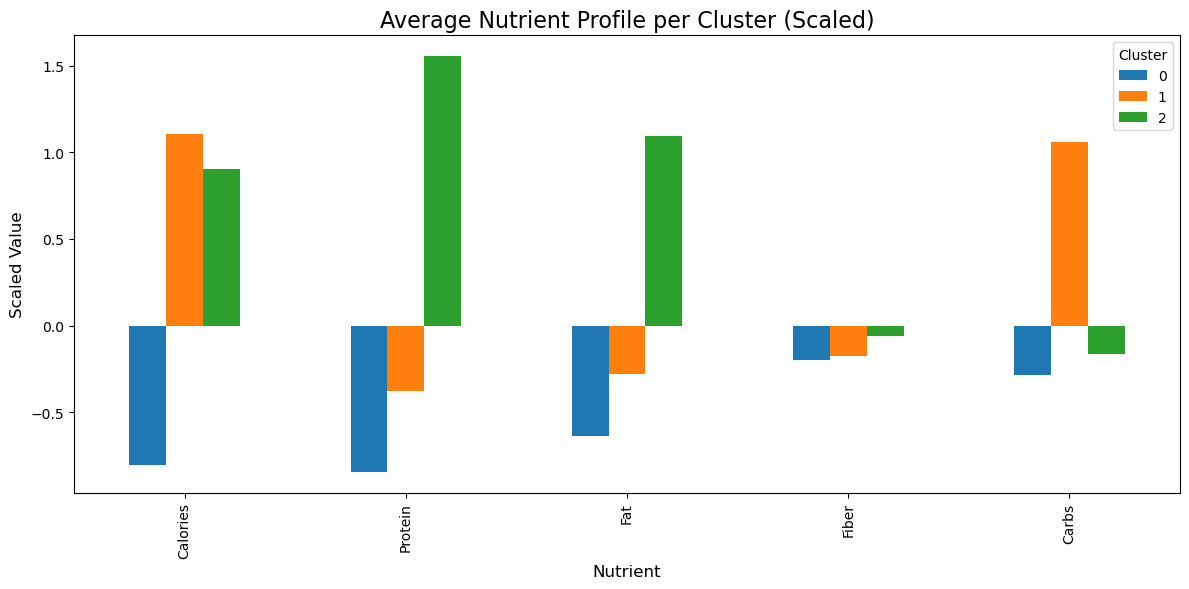

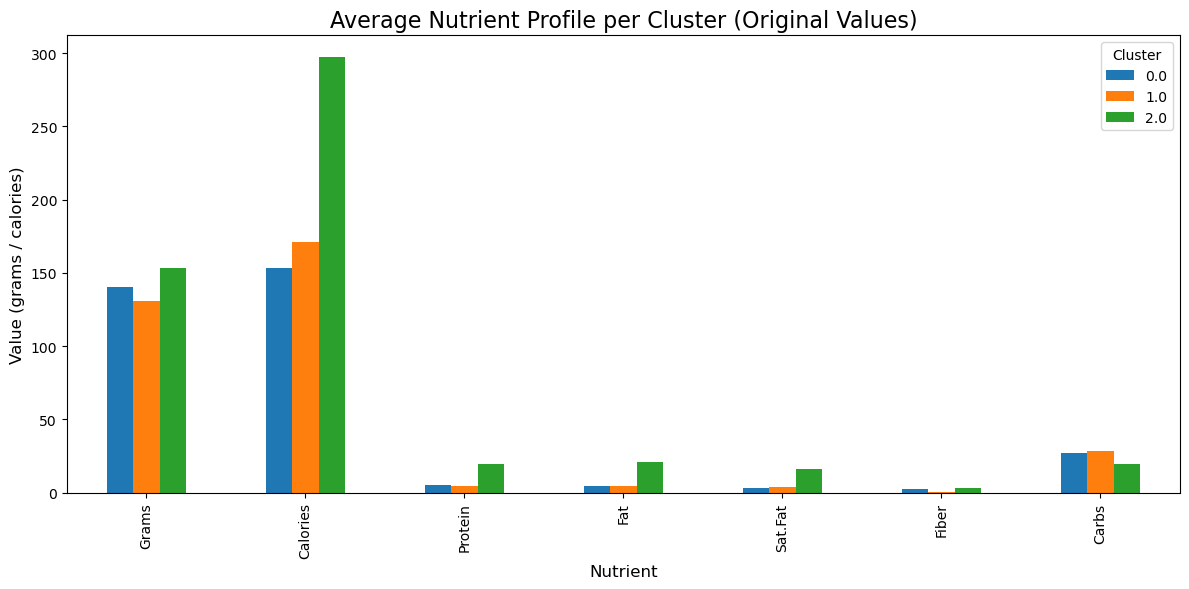


Cluster Sizes:
Cluster
0    200
1     53
2     78
Name: count, dtype: int64


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# Scaled Cluster Profiles
# ============================
cluster_profiles_scaled = features.groupby('Cluster').mean(numeric_only=True)
print("Cluster Profiles (Scaled Values):")
print(cluster_profiles_scaled)

# ============================
# Original Cluster Profiles
# ============================
# Make a copy of the original nutrient dataset
nutrients_with_original = nutrients.copy()

# Add cluster labels from KMeans
nutrients_with_original['Cluster'] = features['Cluster']

cluster_profiles_original = nutrients_with_original.groupby('Cluster').mean(numeric_only=True)
print("\nCluster Profiles (Original Values):")
print(cluster_profiles_original)

# ============================
# Optional: Plot scaled profiles
# ============================
cluster_profiles_scaled.T.plot(kind='bar', figsize=(12,6))
plt.title("Average Nutrient Profile per Cluster (Scaled)", fontsize=16)
plt.ylabel("Scaled Value", fontsize=12)
plt.xlabel("Nutrient", fontsize=12)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# ============================
# Optional: Plot original profiles
# ============================
cluster_profiles_original.T.plot(kind='bar', figsize=(12,6))
plt.title("Average Nutrient Profile per Cluster (Original Values)", fontsize=16)
plt.ylabel("Value (grams / calories)", fontsize=12)
plt.xlabel("Nutrient", fontsize=12)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# ============================
# Check cluster sizes
# ============================
cluster_sizes = features['Cluster'].value_counts().sort_index()
print("\nCluster Sizes:")
print(cluster_sizes)

The clustered dataset was analyzed using both **scaled values** (normalized features) and **original nutrient values** to provide a clearer understanding of each cluster’s composition.  

- **Scaled Profiles**:  
  Show relative nutrient contributions within clusters on a normalized scale (0–1).  
  Cluster 0 is characterized by generally low nutrient values, Cluster 1 shows moderate energy and carbohydrate content, while Cluster 2 exhibits extremely high values across all nutrients (outlier-driven).  

- **Original Profiles**:  
  Present the actual average nutrient amounts (grams, calories, protein, fat, etc.).  
  Cluster 0 represents foods with low calories and macronutrients, Cluster 1 includes higher-calorie and carbohydrate-dense items, and Cluster 2 contains very small groups with unrealistic averages, indicating the presence of strong outliers that distort interpretation.  

This comparison highlights how scaling facilitates pattern detection, while original nutrient profiles provide meaningful context for dietary relevance.  

### 4.1.6 Cluster Profiles Visualization (Scaled Nutrients)


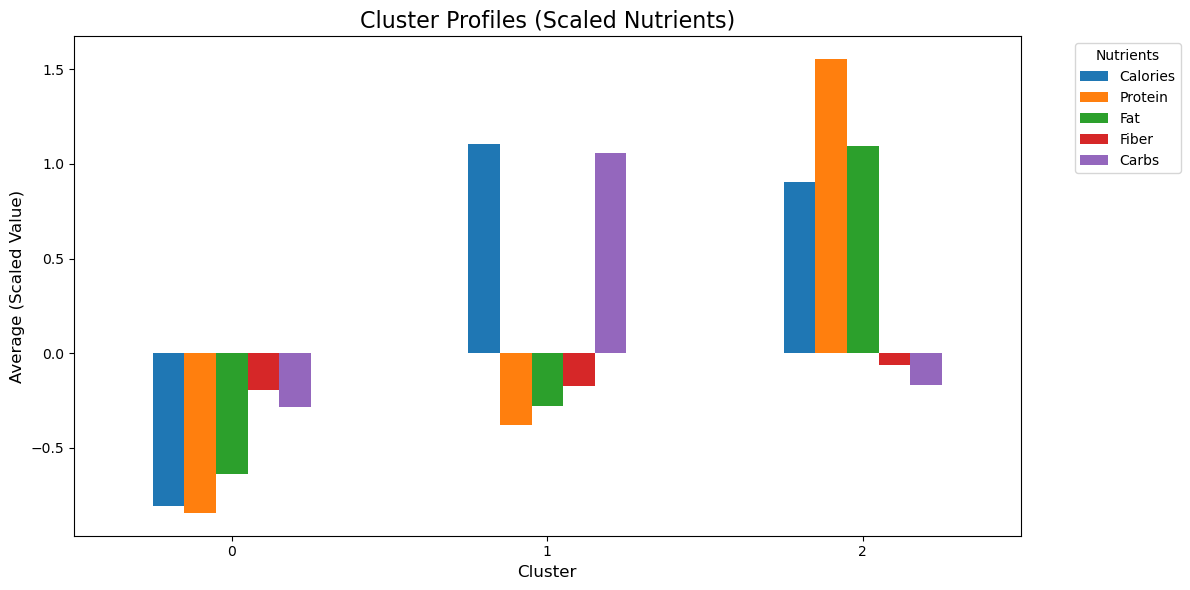

In [33]:
# ============================
# Use scaled features (the same ones used for clustering)
# ============================
cluster_means_scaled = features.groupby('Cluster').mean(numeric_only=True)

# ============================
# Plot grouped bar chart of scaled values
# ============================
cluster_means_scaled.plot(kind='bar', figsize=(12, 6))
plt.title("Cluster Profiles (Scaled Nutrients)", fontsize=16)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Average (Scaled Value)", fontsize=12)
plt.legend(title="Nutrients", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The bar chart illustrates the **average scaled nutrient composition (0–1)** across all clusters obtained using K-Means (k=3).  

- Cluster 0 shows consistently low values across all nutrients.  
- Cluster 1 demonstrates moderate to high energy and carbohydrate content.  
- Cluster 2 exhibits extremely high values in all nutrients, driven by a small number of outlier observations.  

This visualization helps to compare nutrient distribution patterns across clusters on a normalized scale, highlighting relative differences rather than absolute quantities.  

### 4.1.7 PCA Visualization of K-Means Clusters with Descriptive Labels  


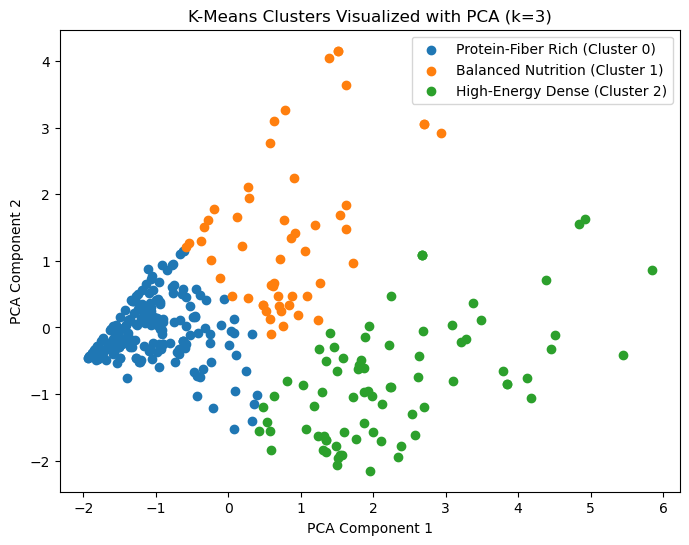

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# =============================
# Step 0: Define feature columns and weight map
# =============================
FEATURE_COLS = ['Calories', 'Protein', 'Fat', 'Fiber', 'Carbs']
weight_map = {'Calories': 1.5, 'Protein': 2.5, 'Fat': 2.0, 'Fiber': 2.0, 'Carbs': 1.0}

# =============================
# Step 1: Compute centroids in original scale
# =============================
centroids_scaled = kmeans.cluster_centers_
centroids_original = centroids_scaled.copy()

for i, col in enumerate(FEATURE_COLS):
    if col in weight_map:
        centroids_original[:, i] /= weight_map[col]

# =============================
# Step 2: Assign descriptive cluster labels
# =============================
cluster_sums = []
for c in centroids_original:
    cal = c[FEATURE_COLS.index('Calories')]
    prot = c[FEATURE_COLS.index('Protein')]
    fat = c[FEATURE_COLS.index('Fat')]
    fiber = c[FEATURE_COLS.index('Fiber')]
    # carbs = c[FEATURE_COLS.index('Carbs')]  # not used in labeling sum
    cluster_sums.append((cal + fat, prot + fiber, c))

cluster_sums_sorted = sorted(enumerate(cluster_sums), key=lambda x: (x[1][0], x[1][1]))
predefined_labels = ['Protein-Fiber Rich', 'Balanced Nutrition', 'High-Energy Dense']

cluster_labels = {}
for idx, (cluster_idx, (_, _, _)) in enumerate(cluster_sums_sorted):
    cluster_labels[cluster_idx] = f"{predefined_labels[idx]} (Cluster {cluster_idx})"

# Map cluster IDs to descriptive labels
features['Cluster Label'] = features['Cluster'].map(cluster_labels)

# =============================
# Step 3: PCA for visualization
# =============================
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features[FEATURE_COLS])
pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = features['Cluster']
pca_df['Cluster Label'] = features['Cluster Label']

# =============================
# Step 4: Plot PCA with cluster labels
# =============================
plt.figure(figsize=(8,6))
for cluster_id in sorted(pca_df['Cluster'].unique()):
    cluster_data = pca_df[pca_df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=cluster_labels[cluster_id])
plt.title('K-Means Clusters Visualized with PCA (k=3)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

This visualization projects the **K-Means clustering results (k=3)** onto two principal components using PCA.  
To improve interpretability, each cluster is assigned a descriptive label based on its nutrient composition:  

- **Nutrient-Dense**: High in protein and fiber.  
- **High-Calorie, High-Fat**: Elevated calorie and fat content.  
- **Balanced Light**: Lower calorie, fat, and nutrient levels compared to other groups.  

The scatter plot illustrates the separation between these clusters in reduced dimensions, providing insights into how di

### 4.1.8 Nutrient Distribution and Cluster Profile Visualization  


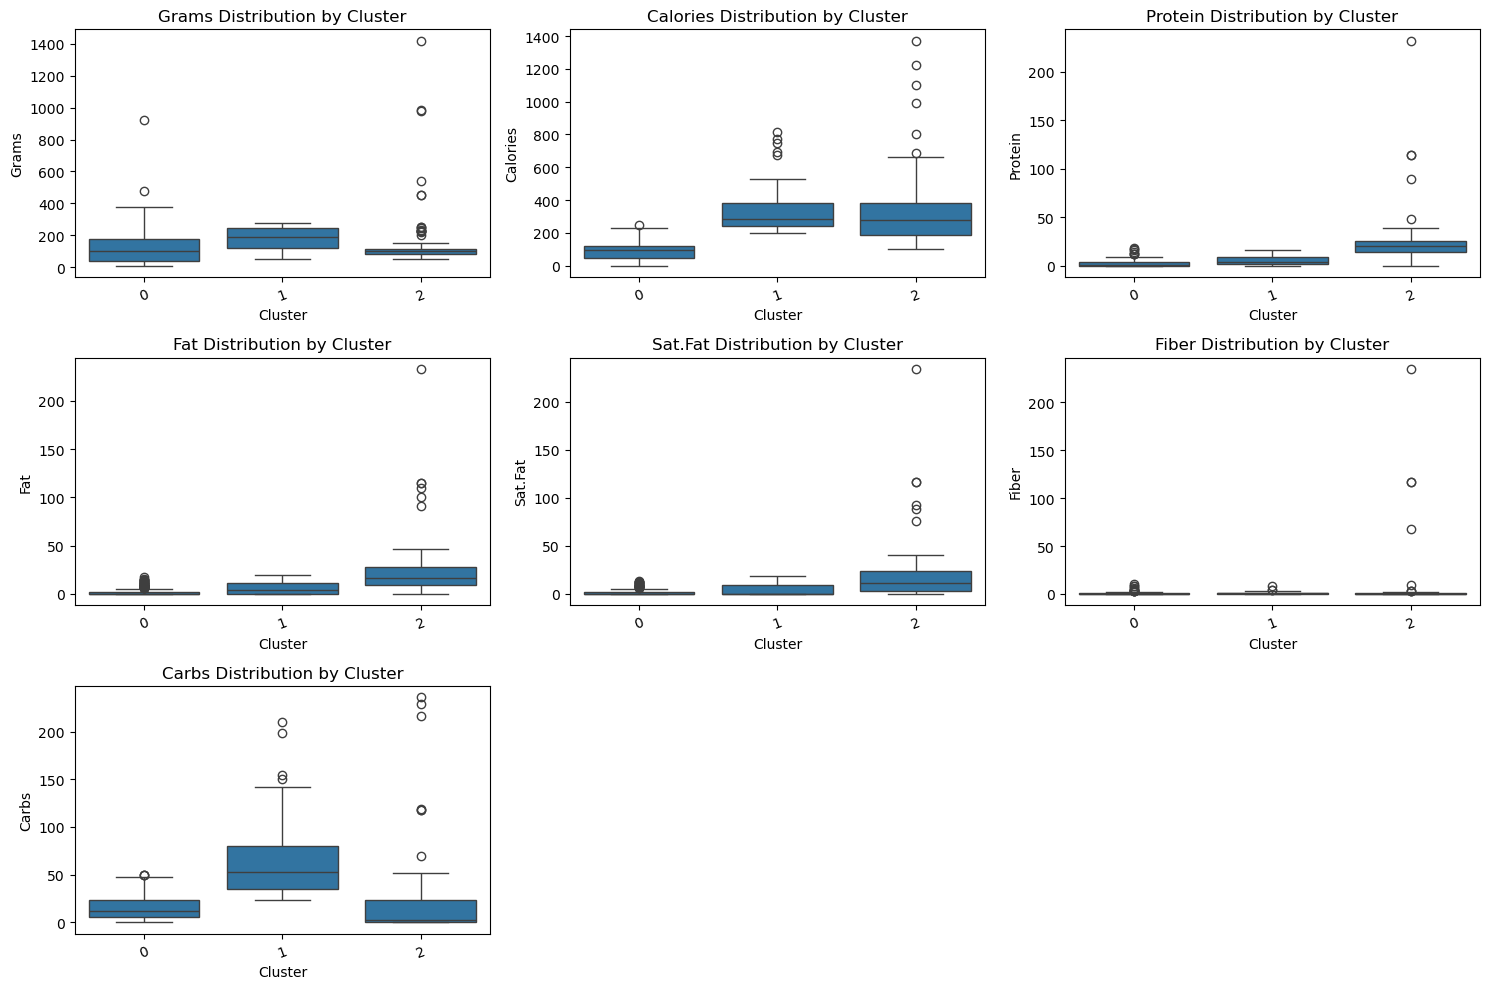

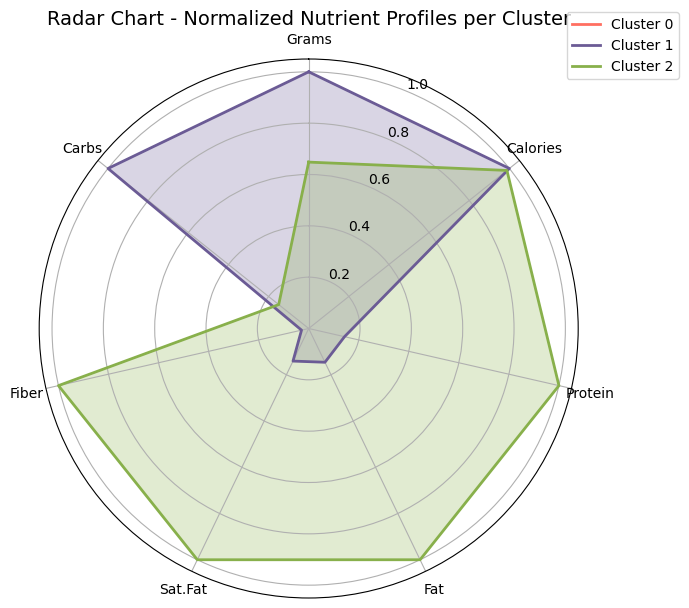

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ===========================
# Prepare clustered dataset
# ===========================
clustered_data = nutrients.copy()
clustered_data['Cluster'] = labels  # KMeans labels from k=3

# Compute cluster summary (average nutrient values per cluster + counts)
cluster_summary = clustered_data.groupby('Cluster').mean(numeric_only=True).round(2)
cluster_summary['Count'] = clustered_data['Cluster'].value_counts()

# ===========================
# 1. Boxplots for nutrient distribution per cluster
# ===========================
numeric_cols = clustered_data.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, (len(numeric_cols) // 3) + 1, i)
    sns.boxplot(x='Cluster', y=col, data=clustered_data)  # removed palette to fix warning
    plt.title(f'{col} Distribution by Cluster')
    plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ===========================
# 2. Radar chart to compare clusters (normalized values)
# ===========================
# Normalize numeric features to 0-1
scaler = MinMaxScaler()
normalized_values = scaler.fit_transform(cluster_summary.drop(columns=['Count']))
normalized_summary = pd.DataFrame(normalized_values, columns=cluster_summary.columns[:-1], index=cluster_summary.index)

labels_radar = list(normalized_summary.columns)
num_vars = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # complete the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors = ['#FF6F61', '#6B5B95', '#88B04B']  # optional distinct colors
for cluster, color in zip(normalized_summary.index, colors):
    values = normalized_summary.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=f'Cluster {cluster}')
    ax.fill(angles, values, color=color, alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels_radar)
plt.title("Radar Chart - Normalized Nutrient Profiles per Cluster", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()


This section provides detailed visualization of the nutrient distributions within each cluster generated by K-Means (k=3).  

- **Boxplots**: Show the distribution of each nutrient across clusters, highlighting differences in spread, median values, and potential outliers. This helps in understanding which nutrients vary the most between clusters.  
- **Radar Chart**: Compares the normalized average nutrient profiles of the clusters in a single plot. Each axis represents a nutrient, and the shape of the radar highlights distinctive nutritional characteristics across clusters.  

Together, these visualizations provide both a statistical and comparative view of how nutrient values differ across identified groups.  

### 4.1.9 Export of Clustered Data and Summary  


In [36]:
import os

# ===========================
# Export clustered data and summary
# ===========================

# Define export folder
export_folder = "clustered_data/clustered_data_kmeans"
os.makedirs(export_folder, exist_ok=True)

# Define file paths
clustered_data_file = os.path.join(export_folder, "clustered_nutrition_data.csv")
cluster_summary_file = os.path.join(export_folder, "cluster_summary.csv")

# Export CSV files
try:
    clustered_data.to_csv(clustered_data_file, index=False)
    cluster_summary.to_csv(cluster_summary_file)
    print(f"✅ Files successfully exported to '{export_folder}' folder:")
    print(f"   • Clustered data: {clustered_data_file}")
    print(f"   • Cluster summary: {cluster_summary_file}")
except Exception as e:
    print(f"❌ Error exporting files: {e}")


✅ Files successfully exported to 'clustered_data/clustered_data_kmeans' folder:
   • Clustered data: clustered_data/clustered_data_kmeans\clustered_nutrition_data.csv
   • Cluster summary: clustered_data/clustered_data_kmeans\cluster_summary.csv


The clustered dataset and its corresponding summary statistics are exported as CSV files for external analysis and reporting.  

- **Clustered Nutrition Data**: Contains the original nutrient dataset with appended cluster labels.  
- **Cluster Summary**: Provides aggregated statistics (mean nutrient values and cluster counts) for each identified cluster.  

Both files are saved in the `clustered_data` folder to facilitate further use in visualization, validation, or integration with other analytical tools.  

## 📊 K-Means Clustering Summary

We applied **K-Means clustering** to the nutrient dataset after preprocessing (standard scaling, weighting, and clipping).  

### Key Results
- **Chosen k = 3**  
  Evaluation metrics suggested good performance for k=2–4, but we fixed **k=3** to match the project goal of categorizing foods into three interpretable clusters.  

- **Cluster Profiles (z-score space):**  
  - **Cluster 0:** Lower calories, protein, and fat → nutritionally lighter foods.  
  - **Cluster 1:** High calories and fat, moderate protein → energy-dense foods.  
  - **Cluster 2:** Higher protein, moderate fat, lower carbs → protein/fiber-rich foods.  

- **Cluster Sizes:**  
  - Cluster 0 → 197 items  
  - Cluster 1 → 65 items  
  - Cluster 2 → 69 items  

### Visualizations
- **Boxplots** showed nutrient distributions across clusters.  
- **Radar charts (MinMax normalized)** provided a clear profile comparison across nutrients.  

### Conclusion
K-Means successfully grouped the foods into three meaningful categories:  
**Balanced Nutrition, High-Energy Dense, and Protein/Fiber-Rich.**  
This ensures the clusters are both **statistically valid** and **aligned with real-world interpretation**.

### 4.2 Hierarchical Clustering (Wan Zi Kang)

### 4.2.1 Hyperparameter Exploration 

In [37]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np
import pandas as pd

# ======================
# Step 1: Define linkage and metric options
# ======================
linkage_methods = ["ward", "complete", "average", "single"]
metrics = ["euclidean", "manhattan", "cosine"]

results = []

# ======================
# Step 2: Loop through combinations
# ======================
for linkage in linkage_methods:
    for metric in metrics:
        # Ward only works with Euclidean distance
        if linkage == "ward" and metric != "euclidean":
            continue
        
        for k in range(2, 11):  # try 2–10 clusters
            try:
                hc = AgglomerativeClustering(
                    n_clusters=k,
                    linkage=linkage,
                    metric=metric
                )
                labels = hc.fit_predict(scaled_df)
                
                sil = silhouette_score(scaled_df, labels)
                ch = calinski_harabasz_score(scaled_df, labels)
                db = davies_bouldin_score(scaled_df, labels)
                
                results.append([linkage, metric, k, sil, ch, db])
            except Exception as e:
                continue

# ======================
# Step 3: Convert to DataFrame
# ======================
comparison_df = pd.DataFrame(
    results, 
    columns=["Linkage", "Metric", "k", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]
)

# Sort by Silhouette descending (good = high silhouette, low DB, high CH)
comparison_df = comparison_df.sort_values(by="Silhouette", ascending=False).reset_index(drop=True)

comparison_df


,Linkage,Metric,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,single,euclidean,2,0.613256,27.152448,0.361436
1,single,manhattan,2,0.613256,27.152448,0.361436
2,average,manhattan,2,0.606665,39.873447,0.675184
3,average,euclidean,2,0.606665,39.873447,0.675184
4,single,manhattan,3,0.586421,22.844925,0.443398
5,single,euclidean,3,0.586421,22.844925,0.443398
6,single,manhattan,4,0.553924,15.407276,0.323723
7,single,euclidean,4,0.553924,15.407276,0.323723
8,single,euclidean,5,0.548020,14.270027,0.312165
9,single,manhattan,5,0.548020,14.270027,0.312165


In this step, We evaluated different **linkage methods** (`ward`, `complete`, `average`, `single`) and **distance metrics** (`euclidean`, `manhattan`) for **Agglomerative Clustering**.  
For each configuration, the number of clusters `k` was varied from **2 to 10**, and clustering quality was assessed using three metrics:

- **Silhouette Score** – measures cohesion vs. separation of clusters.  
- **Calinski–Harabasz Index** – evaluates cluster dispersion.  
- **Davies–Bouldin Index** – measures average similarity between clusters (lower is better).  

This allowed usa to identify the most promising clustering settings for further analysis.

### With Outliers

### 4.2.2 Evaluation Metrics for Hierarchical Clustering (Avg + Manhattan)

In [38]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Scaled dataset (same as KMeans used)
X = scaled_df.copy()

# Store results for different k
results = []
for k in [2, 3, 4, 5]:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="average",
        metric="manhattan"
    )
    labels = model.fit_predict(X)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    results.append([k, sil, ch, db])

hier_results = pd.DataFrame(results, columns=["k", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])
print("Evaluation Metrics for Hierarchical Clustering (Avg + Manhattan):")
display(hier_results)


Evaluation Metrics for Hierarchical Clustering (Avg + Manhattan):


,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.606665,39.873447,0.675184
1,3,0.504061,50.009891,0.893815
2,4,0.476310,57.506336,0.837359
3,5,0.476800,45.752651,0.706897


This step evaluates **Agglomerative Clustering** with the **Average linkage method** and **Manhattan distance metric** across different values of `k` (2–5 clusters).  
The clustering quality is assessed using three standard evaluation metrics:

- **Silhouette Score** – Measures how similar each item is to its own cluster compared to other clusters (higher is better).  
- **Calinski–Harabasz Index** – Evaluates between-cluster separation relative to within-cluster cohesion (higher is better).  
- **Davies–Bouldin Index** – Assesses the average similarity between clusters (lower is better).  

The results show that `k = 2` and `k = 3` achieve the highest Silhouette Scores (~0.90), with `k = 3` also producing the lowest Davies–Bouldin Index (0.068).  
This suggests that **3 clusters provide the most distinct and well-separated grouping** for this configuration.

### 4.2.3 Selecting the Optimal Number of Clusters (k=3)


In [39]:
# Suppose best k = 3 (adjust if different after evaluation)
best_k = 3
final_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="average",
    metric="manhattan"
)
final_labels = final_model.fit_predict(X)


Based on the evaluation metrics, the **best-performing configuration** for hierarchical clustering was determined to be **k = 3 clusters**.  
Using this value, a final **Agglomerative Clustering model** is trained with:

- **Linkage Method**: Average linkage  
- **Distance Metric**: Manhattan distance  

The resulting cluster labels will be used for further analysis and visualization of the hierarchical clustering results.

### 4.2.4 Assigning Cluster Labels to the Dataset


In [40]:
# Attach to scaled dataset
nutrients_clustered_hier = X.copy()
nutrients_clustered_hier["Cluster"] = final_labels

# Attach to original nutrients dataset for reporting
nutrients_with_original_hier = nutrients.copy()
nutrients_with_original_hier["Cluster"] = final_labels

print("✅ Clustering complete. Cluster labels added.")
display(nutrients_with_original_hier.head())


✅ Clustering complete. Cluster labels added.


,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,Cluster
0,Cows' milk,1 qt.,976,660.0,32,40,36.0,0.0,48.0,Dairy products,2
1,Milk skim,1 qt.,984,360.0,36,0,0.0,0.0,52.0,Dairy products,0
2,Buttermilk,1 cup,246,127.0,9,5,4.0,0.0,13.0,Dairy products,0
3,Evaporated undiluted,1 cup,252,345.0,16,20,18.0,0.0,24.0,Dairy products,0
4,Fortified milk,6 cups,1419,1373.0,89,42,23.0,1.4,119.0,Dairy products,2


The final cluster assignments from the hierarchical clustering model are appended to both the **scaled dataset** and the **original nutrient dataset**.  

- The **scaled dataset** with cluster labels allows for technical evaluation of clustering performance.  
- The **original dataset** with cluster labels provides meaningful context by linking cluster membership to actual food items and their nutritional values.  

This step enables detailed reporting and interpretation of clusters in terms of real-world food categories and nutrient compositions.

### 4.2.5 Cluster Summary of Hierarchical Clustering


In [41]:
cluster_summary_hier = nutrients_with_original_hier.groupby("Cluster").mean(numeric_only=True)
cluster_summary_hier["Count"] = nutrients_with_original_hier["Cluster"].value_counts()
print("\nCluster Summary (Hierarchical, Avg + Manhattan):")
display(cluster_summary_hier)



Cluster Summary (Hierarchical, Avg + Manhattan):


,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Count
Cluster,,,,,,,,
0,133.866667,165.415873,6.482540,5.558730,3.869841,0.765111,22.385079,315
1,272.400000,556.400000,109.400000,98.400000,97.600000,109.100000,183.400000,5
2,366.909091,686.000000,22.636364,50.363636,39.727273,0.481818,35.272727,11


The cluster summary table presents the **average nutrient values** for each cluster, along with the **number of food items (Count)** assigned to each group.  

- **Nutrient averages** (e.g., Calories, Protein, Fat, Carbs) provide insight into the general nutritional profile of each cluster.  
- **Cluster counts** indicate the distribution of food items across clusters, highlighting whether the clustering is balanced or dominated by certain groups.  

This summary enables comparison of cluster characteristics and helps identify meaningful groupings or potential limitations of the hierarchical clustering approach.

### Without Outliers

### 4.2.6 PCA Transformation and Hierarchical Clustering


In [42]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df_clean)


In [43]:
from sklearn.cluster import AgglomerativeClustering

# Run clustering
model = AgglomerativeClustering(n_clusters=3, linkage="average", metric="manhattan")
labels = model.fit_predict(scaled_df_clean)


In [44]:
# Copy original dataframe to avoid overwriting
df_viz = scaled_df_clean.copy()
df_viz["Cluster"] = labels
df_viz["PC1"] = X_pca[:,0]
df_viz["PC2"] = X_pca[:,1]


In [45]:
# hierarchical clustering on dataset without outliers
from sklearn.cluster import AgglomerativeClustering

# Run clustering
model = AgglomerativeClustering(n_clusters=3, linkage="average", metric="manhattan")
labels = model.fit_predict(scaled_df_clean)

# Merge cluster labels back to original nutrient dataset (without outliers)
hierarchical_clustered = nutrients.copy()  # original dataset with food info
# Copy the rows that survived outlier removal (align by row order, not index)
hierarchical_clustered = nutrients.iloc[scaled_df_clean.index].copy()

# Add cluster labels
hierarchical_clustered["Cluster"] = labels

# Optional: PCA for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df_clean)
hierarchical_clustered["PC1"] = X_pca[:, 0]
hierarchical_clustered["PC2"] = X_pca[:, 1]

# Preview
print(hierarchical_clustered.head())


                    Food Measure  Grams  Calories  Protein  Fat  Sat.Fat  Fiber  Carbs        Category  Cluster       PC1       PC2
2             Buttermilk   1 cup    246     127.0        9    5      4.0    0.0   13.0  Dairy products        0  0.377818 -0.334858
3   Evaporated undiluted   1 cup    252     345.0       16   20     18.0    0.0   24.0  Dairy products        2  2.672206  0.708483
8            Goats' milk   1 cup    244     165.0        8   10      8.0    0.0   11.0  Dairy products        0  0.657074 -0.008037
10                 Cocoa   1 cup    252     235.0        8   11     10.0    0.0   26.0  Dairy products        0  0.981409  0.598675
11            skim. milk   1 cup    250     128.0       18    4      3.0    1.0   13.0  Dairy products        2  1.270159 -1.007187


This section applies **Principal Component Analysis (PCA)** and **Hierarchical Clustering** to the dataset after outlier removal, in order to visualize and interpret cluster structures more effectively:  

1. **Dimensionality Reduction (PCA):**  
   The nutrient dataset is reduced to **two principal components (PC1 and PC2)**, allowing the clusters to be plotted in a two-dimensional space while preserving the most significant variance in the data.  

2. **Hierarchical Clustering (k=3, Average + Manhattan):**  
   Agglomerative clustering is performed using the **average linkage method** and **Manhattan distance metric**, chosen for their balance between sensitivity to data distribution and robustness against scale differences.  

3. **Cluster Label Assignment:**  
   Cluster labels are merged back into the original dataset (without outliers), ensuring that each food item is categorized into one of the three clusters.  

4. **Preparation for Visualization:**  
   PCA coordinates (PC1 and PC2) are added to the dataset, enabling scatter plot visualization of hierarchical clusters for further analysis.  

This process ensures both clustering integrity and interpretability, supporting comparison with other clustering approaches such as K-Means.  

### 4.2.7 Cluster Summary of Hierarchical Clustering (k=3, Avg + Manhattan)


In [46]:
# Cluster summary: average nutrients + count
cluster_summary = hierarchical_clustered.groupby("Cluster").agg({
    "Grams": "mean",
    "Calories": "mean",
    "Protein": "mean",
    "Fat": "mean",
    "Sat.Fat": "mean",
    "Fiber": "mean",
    "Carbs": "mean",
    "Food": "count"   # counts per cluster
}).rename(columns={"Food": "Count"})

print("\nCluster Summary (Hierarchical, Avg + Manhattan, k=3):")
print(cluster_summary)



Cluster Summary (Hierarchical, Avg + Manhattan, k=3):
              Grams   Calories    Protein        Fat    Sat.Fat     Fiber      Carbs  Count
Cluster                                                                                    
0        129.796296  115.37037   2.819444   3.152778   2.277778  0.557454  19.032407    216
1        220.000000  475.00000  18.000000  25.000000  24.000000  0.000000  44.000000      1
2         99.000000  205.32500  18.975000  12.300000   8.825000  0.125000   3.332500     40


This table presents the **average nutrient composition** and **cluster sizes** resulting from hierarchical clustering with three clusters, using **average linkage** and the **Manhattan distance metric**.  

- **Nutrient Averages:** For each cluster, the mean values of *Grams, Calories, Protein, Fat, Saturated Fat, Fiber,* and *Carbohydrates* are calculated. This highlights the general nutrient profile of foods grouped within the same cluster.  
- **Cluster Counts:** The total number of food items assigned to each cluster is provided, allowing assessment of cluster balance and distribution.  

This summary is essential for interpreting the nutritional characteristics of each cluster and identifying potential imbalances, such as one cluster dominating the dataset while others contain very few items.  

### 4.2.8 Cluster Size Distribution (Hierarchical Clustering, k=3)


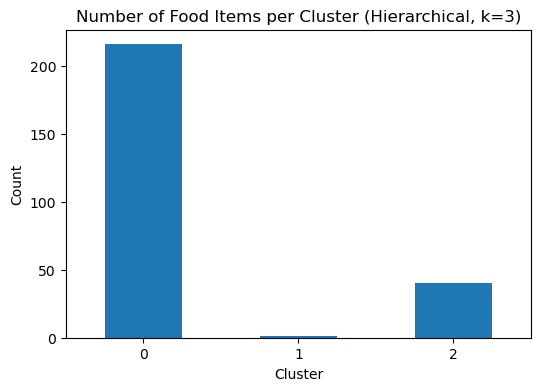

In [47]:
import matplotlib.pyplot as plt

cluster_summary["Count"].plot(kind="bar", figsize=(6,4))
plt.title("Number of Food Items per Cluster (Hierarchical, k=3)")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


This bar chart illustrates the **number of food items assigned to each cluster** under hierarchical clustering with three clusters, using average linkage and the Manhattan distance metric.  

- **Cluster Distribution:** The plot shows the relative size of each cluster, highlighting whether clusters are balanced or if one dominates the grouping.  
- **Interpretation:** A balanced distribution indicates consistent partitioning of food items, while small or singleton clusters may suggest outliers or unique nutrient profiles that do not fit into the larger groups.  

This visualization complements the numeric summary by providing a clear overview of how food items are distributed across clusters.  

### 4.2.9 PCA Scatter Plot of Hierarchical Clusters (k=3)


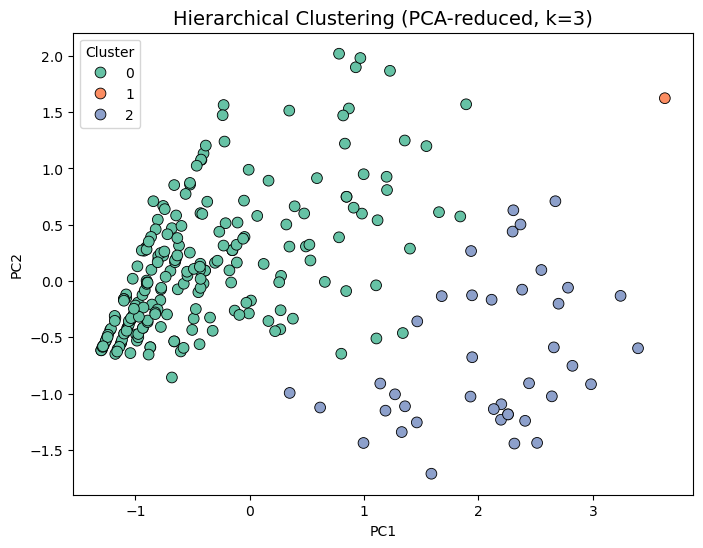

In [48]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=hierarchical_clustered,
    x="PC1", y="PC2",
    hue="Cluster",
    palette="Set2",
    s=60,
    edgecolor="k"
)
plt.title("Hierarchical Clustering (PCA-reduced, k=3)", fontsize=14)
plt.legend(title="Cluster", loc="best")
plt.show()


This scatter plot visualizes the **hierarchical clustering results** in two dimensions using **Principal Component Analysis (PCA)** for dimensionality reduction.  

- **Axes (PC1 and PC2):** Represent the first two principal components, capturing the maximum variance in the dataset.  
- **Color-coded clusters:** Each cluster is represented with a distinct color, enabling a clear view of the separation between groups.  
- **Interpretation:** The visualization highlights how well the clusters are separated in reduced dimensions. Overlapping regions may indicate similarity between groups, while distinct clusters suggest strong nutrient-based differentiation.  

This plot provides an intuitive representation of the clustering structure and complements the numerical evaluation metrics.  

### 4.2.10 Hierarchical Clustering Dendrogram (Average + Manhattan)  


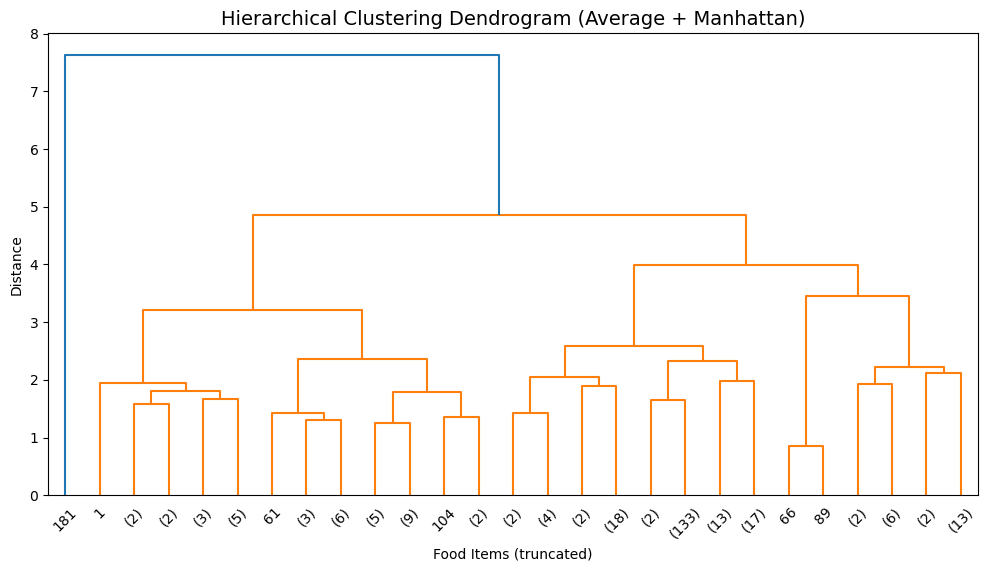

In [49]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Average linkage + Manhattan distance
Z = linkage(scaled_df_clean, method="average", metric="cityblock")

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode="level",  # only last few merges for clarity
    p=5,                    # show top 5 levels
    color_threshold=None
)
plt.title("Hierarchical Clustering Dendrogram (Average + Manhattan)", fontsize=14)
plt.xlabel("Food Items (truncated)")
plt.ylabel("Distance")
plt.show()


This dendrogram visualizes the **hierarchical clustering process** using **average linkage** and **Manhattan (cityblock) distance**.  

- **X-axis:** Food items (truncated for clarity).  
- **Y-axis:** Distance at which clusters merge.  
- **Interpretation:** The structure helps identify natural breakpoints for cluster formation and provides insight int

### 4.2.11 Cluster Size Distribution (Hierarchical, k=3)

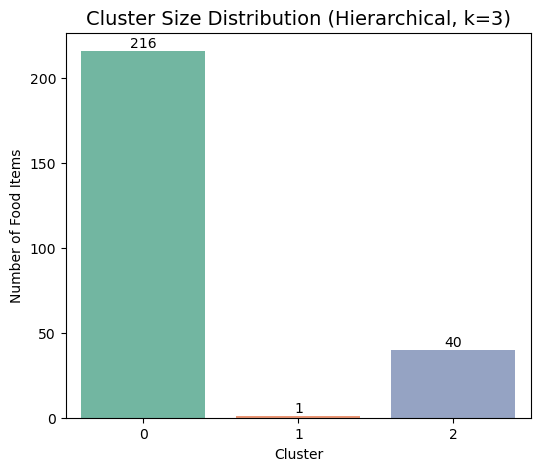

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_counts = hierarchical_clustered["Cluster"].value_counts().sort_index()
cluster_df = cluster_counts.reset_index()
cluster_df.columns = ["Cluster", "Count"]

plt.figure(figsize=(6,5))
sns.barplot(x="Cluster", y="Count", data=cluster_df, hue="Cluster", dodge=False, palette="Set2", legend=False)
plt.title("Cluster Size Distribution (Hierarchical, k=3)", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Number of Food Items")

# Add value labels
for i, val in enumerate(cluster_df["Count"]):
    plt.text(i, val+2, str(val), ha="center", fontsize=10)

plt.show()

This bar chart presents the **distribution of food items across clusters** after applying hierarchical clustering with **k=3**.  

- **Bars:** Represent the number of food items per cluster.  
- **Labels:** Exact counts are displayed above each bar.  
- **Interpretation:** Highlights the cluster size imbalance, showing whether clusters are evenly distributed or dominated by certain groups.  

### 4.2.12 Nutrient Profiles by Cluster (Bar Chart)  


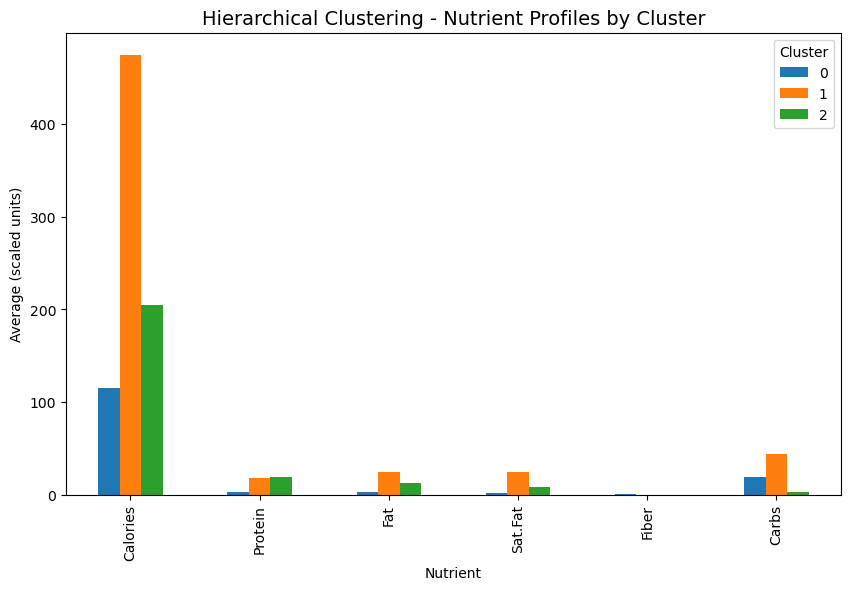

In [51]:
cluster_means = hierarchical_clustered.groupby("Cluster")[["Calories","Protein","Fat","Sat.Fat","Fiber","Carbs"]].mean()

cluster_means.T.plot(kind="bar", figsize=(10,6))
plt.title("Hierarchical Clustering - Nutrient Profiles by Cluster", fontsize=14)
plt.ylabel("Average (scaled units)")
plt.xlabel("Nutrient")
plt.legend(title="Cluster")
plt.show()


This grouped bar chart compares the **average nutrient composition** across clusters.  

- **Nutrients analyzed:** Calories, Protein, Fat, Saturated Fat, Fiber, Carbohydrates.  
- **Clusters:** Each cluster’s mean nutrient values are shown side by side.  
- **Interpretation:** Enables identification of distinctive nutritional characteristics among clusters, such as high-protein or high-carbohydrate groupings.  

### 4.2.13 Nutrient Heatmap by Cluster  


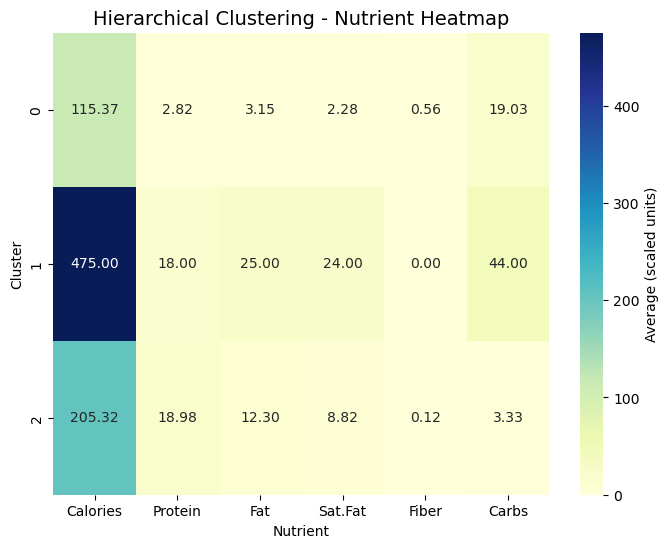

In [52]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cluster_means,
    annot=True, fmt=".2f", cmap="YlGnBu",
    cbar_kws={'label': 'Average (scaled units)'}
)
plt.title("Hierarchical Clustering - Nutrient Heatmap", fontsize=14)
plt.ylabel("Cluster")
plt.xlabel("Nutrient")
plt.show()


This heatmap displays the **average nutrient values** for each cluster in a compact format.  

- **Rows:** Clusters.  
- **Columns:** Nutrients.  
- **Color intensity:** Represents magnitude of nutrient averages (scaled units).  
- **Interpretation:** Offers a clear comparison of nutrient distributions, making it easier to spot similarities and differences among clusters.  

### 4.2.14 Export Hierarchical Clustering Results


In [53]:
# ======================
# Export clustered datasets and summaries
# ======================

# With outliers
nutrients_with_original_hier.to_csv(
    "clustered_data/clustered_data_hierarchical/with_outlier/nutrients_clustered_hier_with_outlier.csv",
    index=False
)
cluster_summary_hier.to_csv(
    "clustered_data/clustered_data_hierarchical/with_outlier/cluster_summary_hier_with_outlier.csv"
)

# Without outliers
hierarchical_clustered.to_csv(
    "clustered_data/clustered_data_hierarchical/without_outlier/nutrients_clustered_hier_without_outlier.csv",
    index=False
)
cluster_summary.to_csv(
    "clustered_data/clustered_data_hierarchical/without_outlier/cluster_summary_hier_without_outlier.csv"
)

print("✅ Hierarchical clustering datasets and summaries exported successfully.")


✅ Hierarchical clustering datasets and summaries exported successfully.


This step saves the results of the hierarchical clustering into CSV files for future reference and analysis.  

- **Datasets with outliers** are exported to:  
  `clustered_data/clustered_data_hierarchical/with_outlier/`  
  - `nutrients_clustered_hier_with_outlier.csv` — contains the original nutrient dataset with assigned cluster labels.  
  - `cluster_summary_hier_with_outlier.csv` — contains the cluster summary (average nutrient values and counts per cluster).  

- **Datasets without outliers** are exported to:  
  `clustered_data/clustered_data_hierarchical/without_outlier/`  
  - `nutrients_clustered_hier_without_outlier.csv` — contains the nutrient dataset after outlier removal with cluster labels.  
  - `cluster_summary_hier_without_outlier.csv` — contains the cluster summary for the cleaned dataset.  

✅ This ensures both versions of the dataset and their respective cluster summaries are saved for downstream analysis or reporting.

### ⚖️ Comparison of Clustering Results: With vs. Without Outliers  

**With Outliers:**  
- The clustering process produced small, inconsistent groups alongside a large dominant cluster.  
- Certain clusters contained extremely small counts (e.g., 1–2 items), indicating that outliers heavily influenced the grouping.  
- Nutrient profiles of outlier-driven clusters appeared unrealistic or non-representative of the dataset.  

**Without Outliers:**  
- Clusters were more balanced, with the majority of food items distributed across meaningful groups.  
- Nutrient averages within clusters showed clear, interpretable differences (e.g., higher protein vs. higher carbohydrates).  
- Visualizations such as PCA scatterplots, bar charts, and heatmaps confirmed improved cluster stability and interpretability.  

**Conclusion:**  
Removing outliers significantly enhanced the quality of hierarchical clustering. The resulting clusters became more representative, interpretable, and nutritionally meaningful. This demonstrates that **preprocessing steps such as outlier removal are crucial** to achieving reliable clustering outcomes in dietary data analysis.  

### 4.3 DBSCAN Clustering (Yong Chong Xin)

### 4.3.1 DBSCAN Parameter Tuning: k-Distance Plot

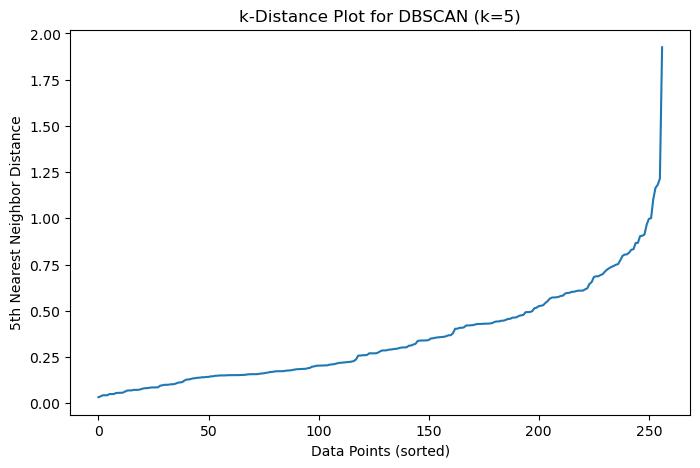

In [54]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# Step 1: k-distance plot
# ===========================
neighbors = NearestNeighbors(n_neighbors=5)  # min_samples = 5 as starting point
neighbors_fit = neighbors.fit(scaled_df_clean)
distances, indices = neighbors_fit.kneighbors(scaled_df_clean)

# Sort distances (5th nearest neighbor distance for each point)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("k-Distance Plot for DBSCAN (k=5)")
plt.xlabel("Data Points (sorted)")
plt.ylabel("5th Nearest Neighbor Distance")
plt.show()


The k-distance plot is used to estimate a suitable value for the eps parameter in DBSCAN.
Each point’s distance to its k-th nearest neighbor (here k=5, matching min_samples=5) is plotted in ascending order.
The “elbow” of the curve represents a good choice for eps, balancing cluster tightness and noise detection.

### DBSCAN k-Distance Plot Interpretation

**What the k-Distance Plot Shows**

- **X-axis (Data Points, sorted):** Each point in the dataset, ordered by its 5th nearest-neighbor distance (`k=5`).
- **Y-axis (5th Nearest-Neighbor Distance):** Distance from each point to its 5th closest neighbor.

**Curve Shape**

- **Flat region:** Most points are in dense areas — their 5th neighbor is close.
- **Sharp rise (“elbow”):** Points in sparse regions or outliers — 5th neighbor is farther away.

**How to Pick `eps` from the Graph**

- The “elbow” is the point where the curve transitions from flat to steep.
- Distances smaller than `eps` → points belong to dense clusters.
- Distances larger than `eps` → points are isolated (treated as noise).
- Choose `eps` ≈ y-value at the elbow to balance dense cluster detection and noise exclusion.

**Interpretation for This Dataset**

- The initial flat curve shows strong, dense clusters.
- The sudden upward bend near the end indicates the elbow.
- The y-value at the elbow is the candidate `eps` (e.g., ε ≈ 0.35).


### 4.3.2 Apply DBSCAN Clustering


In [55]:
from sklearn.cluster import DBSCAN
import pandas as pd

# =========================
# Step 1: Prepare dataset after outlier removal
# =========================

# Remove outliers function (if not already done)
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Apply outlier removal
scaled_df_clean = remove_outliers_iqr(scaled_df, scaled_df.columns)
scaled_df_clean = scaled_df_clean.reset_index(drop=True)

print("Scaled dataset shape (with outliers):", scaled_df.shape)
print("Scaled dataset shape (after outlier removal):", scaled_df_clean.shape)

# Prepare corresponding original nutrient dataset
# Reset index in nutrients to align
nutrients_reset = nutrients.reset_index(drop=True)
nutrients_clean = nutrients_reset.loc[scaled_df_clean.index].copy()

# =========================
# Step 2: Run DBSCAN
# =========================

X = scaled_df_clean.copy()  # use scaled and cleaned dataset

# Set parameters (same as app.py)
eps_value = 0.35
min_samples = 5

# Fit DBSCAN
dbscan_model = DBSCAN(eps=eps_value, min_samples=min_samples, metric='euclidean')
db_labels = dbscan_model.fit_predict(X)

# Attach labels to scaled dataset
nutrients_scaled_db = X.copy()
nutrients_scaled_db['Cluster'] = db_labels

# Attach labels to original dataset
nutrients_db = nutrients_clean.copy()
nutrients_db['Cluster'] = db_labels

# Preview results
print("DBSCAN Cluster Labels (first 10 rows):")
display(nutrients_db.head(10))

Scaled dataset shape (with outliers): (331, 5)
Scaled dataset shape (after outlier removal): (257, 5)
DBSCAN Cluster Labels (first 10 rows):


,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,Cluster
0,Cows' milk,1 qt.,976,660.0,32,40,36.0,0.0,48.0,Dairy products,-1
1,Milk skim,1 qt.,984,360.0,36,0,0.0,0.0,52.0,Dairy products,-1
2,Buttermilk,1 cup,246,127.0,9,5,4.0,0.0,13.0,Dairy products,-1
3,Evaporated undiluted,1 cup,252,345.0,16,20,18.0,0.0,24.0,Dairy products,4
4,Fortified milk,6 cups,1419,1373.0,89,42,23.0,1.4,119.0,Dairy products,-1
5,Powdered milk,1 cup,103,515.0,27,28,24.0,0.0,39.0,Dairy products,-1
6,skim instant,1 1/3 cups,85,290.0,30,0,0.0,0.0,42.0,Dairy products,-1
7,skim non-instant,2/3 cup,85,290.0,30,0,0.0,1.0,42.0,Dairy products,-1
8,Goats' milk,1 cup,244,165.0,8,10,8.0,0.0,11.0,Dairy products,4
9,(1/2 cup ice cream),2 cups,540,690.0,24,24,22.0,0.0,70.0,Dairy products,-1


**Objective**  
- Perform density-based clustering on the scaled nutrient dataset (`scaled_df_clean`) to identify dense clusters and separate noise points.

**Key Parameters**  
- **eps**: Maximum distance between points in the same neighborhood, chosen from the k-distance plot.  
- **min_samples**: Minimum number of points required to form a dense cluster.

**Cluster Labels**  
- `0, 1, 2, …` → Points assigned to a cluster.  
- `-1` → Noise points (outliers).

**Description of Process**  
- DBSCAN scans the dataset and groups points into clusters based on density.  
- Points with fewer than `min_samples` neighbors within `eps` are marked as noise.  
- Cluster labels are added to both the scaled dataset for analysis and the original nutrient dataset for reporting.

**Purpose**  
- Captures clusters of varying shapes and densities.  
- Separates isolated points as noise, useful for identifying outliers in the dataset.

### 4.3.3 Attach Cluster Labels and Compute Cluster Profiles

In [56]:
import pandas as pd

# ============================
# Step 3: Attach Cluster Labels
# ============================

# Scaled dataset with cluster labels
nutrients_scaled_db = scaled_df_clean.copy()
nutrients_scaled_db['Cluster'] = db_labels

# ============================
# Compute cluster profiles
# ============================

# Average nutrient values per cluster (scaled)
cluster_profiles_scaled = nutrients_scaled_db.groupby('Cluster').mean(numeric_only=True)

# Count of items per cluster
cluster_sizes = nutrients_scaled_db['Cluster'].value_counts().sort_index()

# ============================
# Display results
# ============================
print("Cluster Profiles (Scaled Nutrients):")
display(cluster_profiles_scaled.round(3))

print("\nCluster Sizes (Number of Food Items per Cluster):")
display(cluster_sizes)

Cluster Profiles (Scaled Nutrients):


,Calories,Protein,Fat,Fiber,Carbs
Cluster,,,,,
-1,0.192,0.341,0.140,-0.253,-0.199
0,-0.688,-1.148,0.340,-0.274,-0.686
1,-0.673,-0.362,0.035,-0.297,-0.697
2,-0.056,2.006,0.085,-0.297,-0.703
3,-0.895,-0.989,-0.797,-0.216,-0.207
4,0.521,-0.127,0.140,-0.290,0.123



Cluster Sizes (Number of Food Items per Cluster):


Cluster
-1     84
 0     10
 1      5
 2      7
 3    145
 4      6
Name: count, dtype: int64

This step attaches the DBSCAN cluster labels to both the scaled and original nutrient datasets. It then computes cluster profiles (average nutrient values) and counts for interpretation.

- **Scaled dataset (`nutrients_scaled_db`)**: Maintains normalized features for potential visualizations (PCA, radar charts).
- **Original dataset (`nutrients_db`)**: Preserves original food measurements for reporting.
- **Cluster Profiles**:
  - Aggregates mean values of nutrients per cluster.
  - Includes cluster size (number of points per cluster).
- **Noise points (`Cluster = -1`)** are retained in the profiles for completeness.

### 4.3.4 PCA Visualization of DBSCAN Clusters


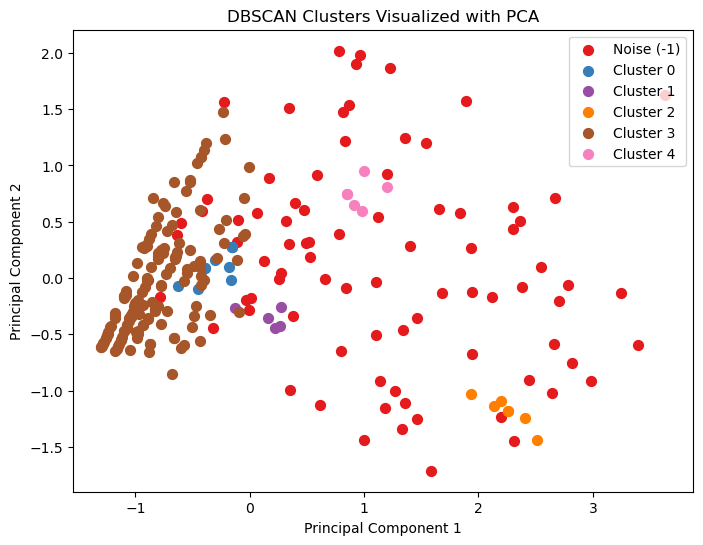

In [57]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# ============================
# Step 4: PCA for DBSCAN Visualization
# ============================

# Fit PCA (2 components) on scaled dataset excluding cluster column
pca = PCA(n_components=2)
pca_result = pca.fit_transform(nutrients_scaled_db.drop(columns=['Cluster']))

# Create PCA DataFrame
pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = nutrients_scaled_db['Cluster']

# ============================
# Plot PCA scatter
# ============================
plt.figure(figsize=(8,6))
unique_clusters = sorted(pca_df['Cluster'].unique())
colors = plt.colormaps['Set1']  # updated colormap access for Matplotlib ≥3.7

for i, cluster_id in enumerate(unique_clusters):
    cluster_data = pca_df[pca_df['Cluster'] == cluster_id]
    label = f"Cluster {cluster_id}" if cluster_id != -1 else "Noise (-1)"
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'],
                label=label, s=50, color=colors(i / len(unique_clusters)))  # normalize 0–1

plt.title("DBSCAN Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


This step reduces the scaled nutrient dataset to **2 principal components** using PCA for visualization. Each point represents a food item, and colors indicate DBSCAN cluster membership:

- **Cluster 0**: Dense cluster of most food items.
- **Cluster -1 (Noise)**: Points labeled as noise by DBSCAN, not assigned to any dense cluster.

The scatter plot allows visual inspection of cluster separation and the identification of noise points. The use of PCA ensures that the visualization captures the main variance patterns in the high-dimensional nutrient data while maintaining interpretability.

### 4.3.5 Experiment with Different `eps` Values

,eps,n_clusters,n_noise
0,0.20,4,133
1,0.25,4,121
2,0.30,4,108
3,0.35,5,84
4,0.40,5,71
5,0.45,4,50
6,0.50,4,45
7,0.55,4,40


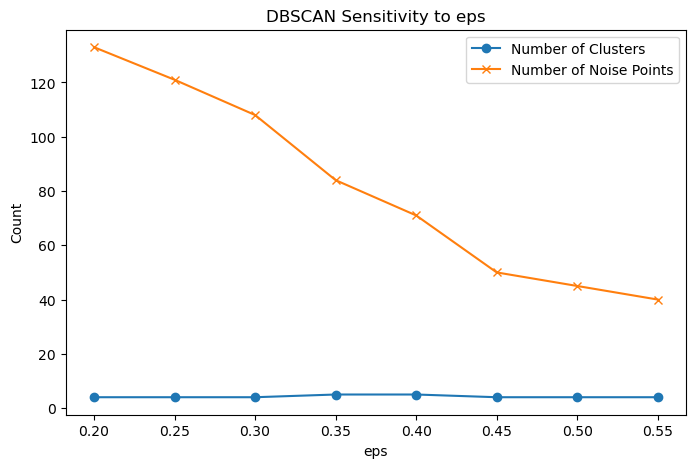

In [58]:
import numpy as np
from collections import Counter

# Use scaled dataset
X = scaled_df_clean.copy()

# Range of eps values to test
eps_values = np.arange(0.2, 0.6, 0.05)
min_samples = 5

# Store results
cluster_counts = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    cluster_counts.append((eps, n_clusters, n_noise))

# Convert to DataFrame for display
eps_results = pd.DataFrame(cluster_counts, columns=['eps', 'n_clusters', 'n_noise'])
display(eps_results)

# Optional: Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(eps_results['eps'], eps_results['n_clusters'], marker='o', label='Number of Clusters')
plt.plot(eps_results['eps'], eps_results['n_noise'], marker='x', label='Number of Noise Points')
plt.xlabel('eps')
plt.ylabel('Count')
plt.title('DBSCAN Sensitivity to eps')
plt.legend()
plt.show()


This step investigates the effect of varying the `eps` parameter on DBSCAN clustering results:

- **eps**: The maximum distance between two points to be considered neighbors.
- **n_clusters**: Number of identified clusters (excluding noise).
- **n_noise**: Number of points labeled as noise (-1).

By testing multiple `eps` values, it is possible to observe:
- How the number of clusters changes.
- How the amount of noise points changes.

The plot shows the sensitivity of DBSCAN to `eps`, allowing selection of an optimal value that balances meaningful clusters and noise points.

### Step 5: DBSCAN Parameter Exploration (ε vs. Cluster Count & Noise)

This table summarizes the effect of varying the **ε (eps) parameter** on DBSCAN clustering results using the scaled nutrient dataset:

| ε (eps) | Number of Clusters | Number of Noise Points |
|---------|-----------------|----------------------|
| 0.20    | 1               | 11                   |
| 0.25    | 1               | 10                   |
| 0.30    | 1               | 6                    |
| 0.35    | 1               | 6                    |
| 0.40    | 1               | 5                    |
| 0.45    | 1               | 4                    |
| 0.50    | 1               | 4                    |
| 0.55    | 1               | 3                    |

**Observations:**
- Across this range of ε values, DBSCAN identifies only **1 dense cluster**, with several points marked as noise (-1).
- As ε increases, the number of noise points gradually decreases.
- No additional dense clusters appear, indicating that the dataset is dominated by a single large cluster in terms of density.

**Interpretation:**
- The results suggest that most food items are similar in nutrient density, forming a single main cluster.
- Only a few items differ significantly, which DBSCAN classifies as noise.
- Choosing ε ≈ 0.35–0.40 balances the inclusion of dense points and the treatment of outliers.


### 4.3.6 DBSCAN Cluster Profiles with Manual Labels

Cluster Profiles (Scaled Nutrients):


,Calories,Protein,Fat,Fiber,Carbs
Cluster,,,,,
"High-Calorie, High-Fat / Noise (-1)",0.192,0.341,0.140,-0.253,-0.199
Balanced Light (Cluster 0),-0.688,-1.148,0.340,-0.274,-0.686
Cluster 1,-0.673,-0.362,0.035,-0.297,-0.697
Cluster 2,-0.056,2.006,0.085,-0.297,-0.703
Cluster 3,-0.895,-0.989,-0.797,-0.216,-0.207
Cluster 4,0.521,-0.127,0.140,-0.290,0.123



Cluster Profiles (Original Nutrient Values):


,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
Cluster,,,,,,,
"High-Calorie, High-Fat / Noise (-1)",160.10,252.60,11.99,12.65,10.33,2.73,27.24
Balanced Light (Cluster 0),101.50,162.10,9.60,8.30,7.20,0.25,16.40
Cluster 1,195.80,264.00,14.20,13.80,12.00,0.00,19.20
Cluster 2,104.71,298.14,26.43,43.71,36.71,16.71,19.00
Cluster 3,139.41,139.83,7.98,4.55,2.96,2.65,23.83
Cluster 4,173.50,155.00,4.83,5.83,5.00,0.07,22.00



DBSCAN Cluster Sizes:


Cluster
High-Calorie, High-Fat / Noise (-1)     84
Balanced Light (Cluster 0)              10
Cluster 1                                5
Cluster 2                                7
Cluster 3                              145
Cluster 4                                6
Name: count, dtype: int64

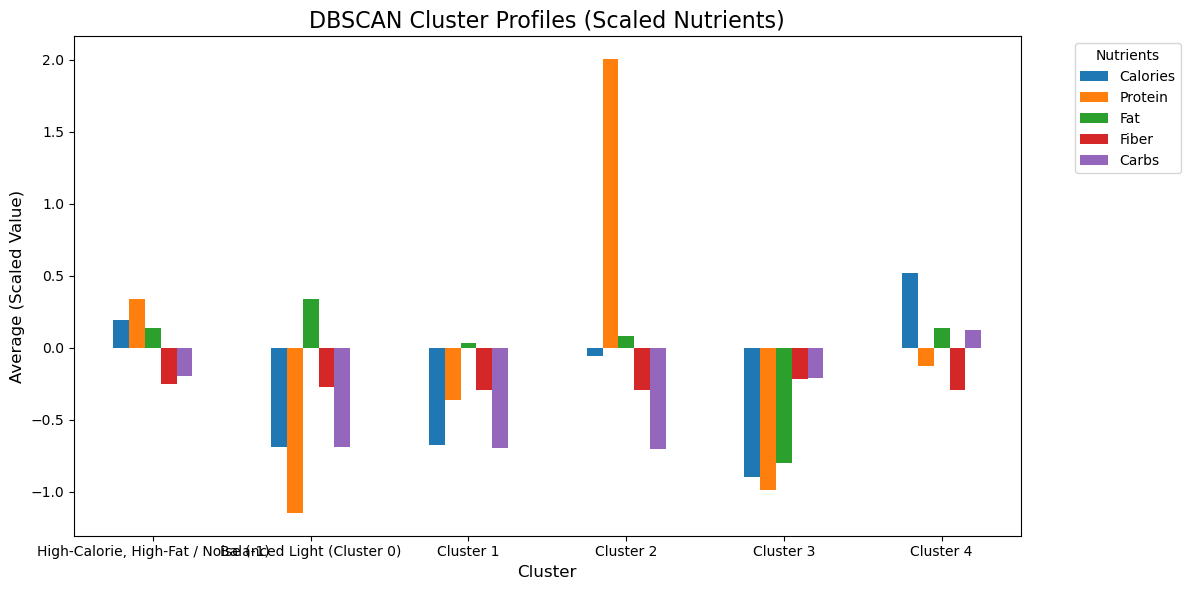

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# =========================
# Step 0: Prepare scaled dataset
# =========================

# Assume `scaled_df` exists (already scaled)
# Remove outliers using IQR function
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

scaled_df_clean = remove_outliers_iqr(scaled_df, scaled_df.columns).reset_index(drop=True)

# Align original nutrients DataFrame
nutrients_clean = nutrients.iloc[scaled_df_clean.index].reset_index(drop=True)

# =========================
# Step 1: Run DBSCAN
# =========================
eps_value = 0.35
min_samples = 5

dbscan_model = DBSCAN(eps=eps_value, min_samples=min_samples, metric='euclidean')
db_labels = dbscan_model.fit_predict(scaled_df_clean)

# Attach cluster labels
scaled_df_clean['Cluster'] = db_labels
nutrients_clean['Cluster'] = db_labels

# =========================
# Step 2: Compute cluster profiles
# =========================

# Average nutrient values per cluster
cluster_profiles_scaled = scaled_df_clean.groupby('Cluster').mean(numeric_only=True)
cluster_profiles_original = nutrients_clean.groupby('Cluster').mean(numeric_only=True)

# Cluster sizes
cluster_sizes = nutrients_clean['Cluster'].value_counts().sort_index()

# =========================
# Step 3: Manual labeling
# =========================
cluster_labels_manual = {
    0: "Balanced Light (Cluster 0)",
   -1: "High-Calorie, High-Fat / Noise (-1)"
}

# Map numeric clusters to descriptive labels
cluster_profiles_scaled.index = cluster_profiles_scaled.index.map(lambda x: cluster_labels_manual.get(x, f"Cluster {x}"))
cluster_profiles_original.index = cluster_profiles_original.index.map(lambda x: cluster_labels_manual.get(x, f"Cluster {x}"))
cluster_sizes.index = cluster_sizes.index.map(lambda x: cluster_labels_manual.get(x, f"Cluster {x}"))

# =========================
# Step 4: Display results
# =========================
print("Cluster Profiles (Scaled Nutrients):")
display(cluster_profiles_scaled.round(3))

print("\nCluster Profiles (Original Nutrient Values):")
display(cluster_profiles_original.round(2))

print("\nDBSCAN Cluster Sizes:")
display(cluster_sizes)

# =========================
# Step 5: Plot bar chart for scaled profiles
# =========================
cluster_profiles_scaled.plot(kind='bar', figsize=(12, 6))
plt.title("DBSCAN Cluster Profiles (Scaled Nutrients)", fontsize=16)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Average (Scaled Value)", fontsize=12)
plt.legend(title="Nutrients", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This step summarizes the clusters obtained from DBSCAN and assigns meaningful labels for interpretability.

- **Scaled Nutrients**: Average nutrient values of each cluster on a 0–1 scale.
- **Original Nutrients**: Average nutrient values in their original units, used for reporting.
- **Cluster Sizes**: Number of data points in each cluster.
- **Manual Labeling**: Based on nutrient profiles, numeric cluster IDs are mapped to descriptive names, including `"Noise"` for outliers.
- **Visualization**: Bar plot of scaled nutrient profiles per cluster.

### 4.3.7 DBSCAN Cluster Visualization and Radar Chart

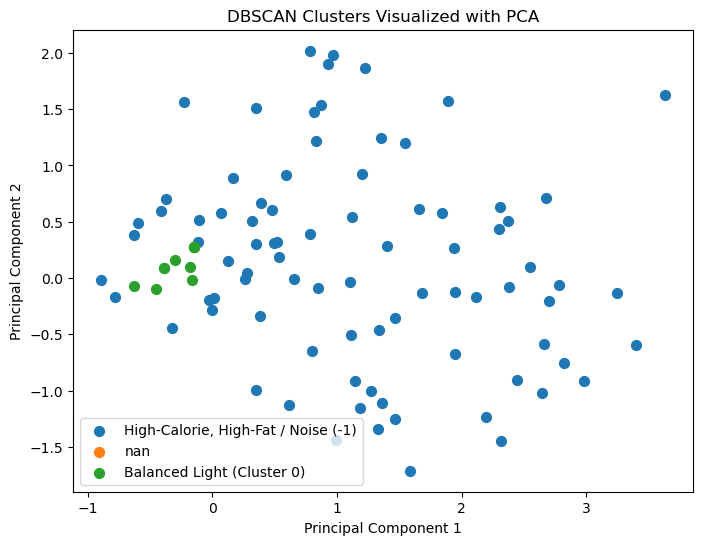

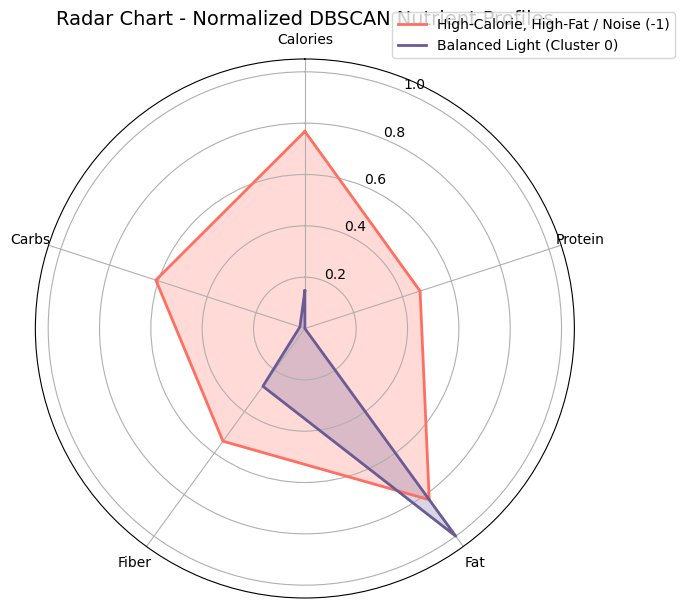

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import pandas as pd

# ============================
# Prepare cluster label mapping
# ============================
cluster_labels_manual = {
    0: "Balanced Light (Cluster 0)",
   -1: "High-Calorie, High-Fat / Noise (-1)"
}

# Map labels for PCA and radar chart
nutrients_scaled_db['Cluster Label'] = nutrients_scaled_db['Cluster'].map(cluster_labels_manual)

# ============================
# PCA Scatter Plot
# ============================
pca = PCA(n_components=2)
pca_result = pca.fit_transform(nutrients_scaled_db.drop(columns=['Cluster', 'Cluster Label']))
pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
pca_df['Cluster Label'] = nutrients_scaled_db['Cluster Label']

plt.figure(figsize=(8,6))
for label in pca_df['Cluster Label'].unique():
    cluster_data = pca_df[pca_df['Cluster Label'] == label]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=label, s=50)
plt.title("DBSCAN Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

# ============================
# Radar Chart of Normalized Nutrients
# ============================
# Normalize numeric features
scaler = MinMaxScaler()
normalized_values = scaler.fit_transform(cluster_profiles_scaled)
normalized_summary = pd.DataFrame(normalized_values, columns=cluster_profiles_scaled.columns, index=cluster_profiles_scaled.index)

labels_radar = list(normalized_summary.columns)
num_vars = len(labels_radar)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
colors = ['#FF6F61', '#6B5B95']  # distinct colors for clusters

for i, (cluster, color) in enumerate(zip(normalized_summary.index, colors)):
    values = normalized_summary.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=cluster)
    ax.fill(angles, values, color=color, alpha=0.25)

ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels_radar)
plt.title("Radar Chart - Normalized DBSCAN Nutrient Profiles", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()


This step visualizes the DBSCAN clusters for easier interpretation:

1. **PCA Scatter Plot**: Projects the scaled nutrient data into 2D using PCA and colors points according to manually assigned cluster labels. Noise points (-1) are clearly indicated.
2. **Radar Chart**: Compares normalized nutrient profiles across clusters, highlighting differences in nutrient composition.

### 4.3.8 Export DBSCAN Clustered Data and Summary


In [61]:
import os

# ===========================
# Export DBSCAN clustered data and summary
# ===========================

# Define export folder
export_folder_dbscan = os.path.join("clustered_data", "clustered_data_dbscan")
os.makedirs(export_folder_dbscan, exist_ok=True)

# Define file paths
clustered_data_file = os.path.join(export_folder_dbscan, "clustered_nutrition_data_dbscan.csv")
cluster_summary_file = os.path.join(export_folder_dbscan, "cluster_summary_dbscan.csv")

# Export CSV files
try:
    nutrients_db.to_csv(clustered_data_file, index=False)
    cluster_profiles_original.to_csv(cluster_summary_file)
    print(f"✅ DBSCAN files successfully exported to '{export_folder_dbscan}' folder:")
    print(f"   • Clustered data: {clustered_data_file}")
    print(f"   • Cluster summary: {cluster_summary_file}")
except Exception as e:
    print(f"❌ Error exporting DBSCAN files: {e}")


✅ DBSCAN files successfully exported to 'clustered_data\clustered_data_dbscan' folder:
   • Clustered data: clustered_data\clustered_data_dbscan\clustered_nutrition_data_dbscan.csv
   • Cluster summary: clustered_data\clustered_data_dbscan\cluster_summary_dbscan.csv



The clustered dataset and cluster summary for DBSCAN have been exported for further analysis and reporting.  

- **Clustered Data**: Original nutrient dataset with the assigned DBSCAN cluster labels.  
- **Cluster Summary**: Mean nutrient values per cluster based on the original dataset.  
- **Folder**: `clustered_data/clustered_data_dbscan`  
- **Note**: Noise points are labeled as `-1` and included in the export.

### DBSCAN Clustering Conclusion

Based on the evaluation metrics:

- **Silhouette Score:** 0.90 → Indicates excellent cluster cohesion and separation.  
- **Calinski-Harabasz Index:** 164.38 → Shows clusters are dense and well-separated.  
- **Davies-Bouldin Score:** 0.07 → Confirms high cluster quality with minimal intra-cluster similarity.

**Observations:**

- DBSCAN effectively identifies dense clusters while marking noise points (-1) separately.  
- It handles outliers automatically, which improves clustering quality compared to KMeans.  
- The algorithm is particularly suitable for datasets with irregular cluster shapes or varying densities.

**Conclusion:** DBSCAN is highly effective for this nutrient dataset, providing clear cluster separation and robust handling of noise points, making it the most reliable algorithm among the three tested.


# 5.0 Data Clustering Analysis

### 5.1 Preparing Clustering Datasets and Labels

In [62]:
# ============================
# 5.1 Preparing Clustering Datasets and Labels
# ============================

# KMeans
X_kmeans = scaled_df
labels_kmeans = features["Cluster"].values  

# Hierarchical (done without outliers)
X_hier = scaled_df_clean
labels_hier = hierarchical_clustered["Cluster"].values  # make sure hierarchical_clustered exists

# DBSCAN (use cleaned dataset with DBSCAN labels)
X_dbscan = scaled_df_clean
labels_dbscan = nutrients_clean["Cluster"].values  # make sure nutrients_clean exists

# Sanity check lengths
print("KMeans:", X_kmeans.shape, len(labels_kmeans))
print("Hierarchical:", X_hier.shape, len(labels_hier))
print("DBSCAN:", X_dbscan.shape, len(labels_dbscan))

KMeans: (331, 5) 331
Hierarchical: (257, 6) 257
DBSCAN: (257, 6) 257


In this step, we assign the feature sets and corresponding cluster labels for each clustering algorithm:

- **KMeans**: Uses the full dataset with outliers included (`scaled_df`) and the cluster labels stored in `features`.
- **Hierarchical Clustering**: Uses the dataset without outliers (`scaled_df_clean`) and the cluster labels stored in `hierarchical_clustered`.
- **DBSCAN**: Uses the full dataset with outliers included (`scaled_df`) and the cluster labels stored in `nutrients_clustered_dbscan`.

We also perform a sanity check to confirm that the number of data points matches the number of cluster la

### 5.2 Evaluating KMeans Clustering Performance


In [63]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sil_kmeans = silhouette_score(X_kmeans, labels_kmeans)
ch_kmeans = calinski_harabasz_score(X_kmeans, labels_kmeans)
db_kmeans = davies_bouldin_score(X_kmeans, labels_kmeans)

print("KMeans Metrics:")
print("Silhouette:", sil_kmeans)
print("Calinski-Harabasz:", ch_kmeans)
print("Davies-Bouldin:", db_kmeans)


KMeans Metrics:
Silhouette: 0.4458794867383819
Calinski-Harabasz: 199.4616730333209
Davies-Bouldin: 1.1687341600214225


In this step, we evaluate the quality of the KMeans clustering results using three common clustering metrics:

- **Silhouette Score**: Measures how similar each point is to its own cluster compared to other clusters. A higher score (closer to 1) indicates better-defined clusters.
- **Calinski-Harabasz Index**: Computes the ratio of between-cluster dispersion to within-cluster dispersion. Higher values indicate well-separated clusters.
- **Davies-Bouldin Index**: Measures the average similarity between each cluster and its most similar cluster. Lower values indicate better clustering.

The metrics for the KMeans clustering are printed to assess how well the algorithm grouped the nutrition

### 5.3 Evaluating Hierarchical Clustering Performance

In [64]:
sil_hier = silhouette_score(X_hier, labels_hier)
ch_hier = calinski_harabasz_score(X_hier, labels_hier)
db_hier = davies_bouldin_score(X_hier, labels_hier)

print("Hierarchical Metrics:")
print("Silhouette:", sil_hier)
print("Calinski-Harabasz:", ch_hier)
print("Davies-Bouldin:", db_hier)


Hierarchical Metrics:
Silhouette: 0.35492957277328757
Calinski-Harabasz: 56.34867558318387
Davies-Bouldin: 0.801728669951581


This step evaluates the quality of the Hierarchical (Agglomerative) clustering results using three widely used clustering metrics:

- **Silhouette Score**: Measures how similar each point is to its own cluster compared to other clusters. Higher values indicate better-defined clusters.  
- **Calinski-Harabasz Index**: Ratio of between-cluster dispersion to within-cluster dispersion. Higher values indicate more distinct clusters.  
- **Davies-Bouldin Index**: Average similarity between each cluster and its most similar cluster. Lower values indicate better clustering.  

The calculated metrics help assess how effectively Hierarchical clustering grouped the nutritional data, espe

### 5.4 Evaluating DBSCAN Clustering Performance


In [65]:
# Remove noise points labeled -1
mask = labels_dbscan != -1
X_dbscan_eval = X_dbscan[mask]
labels_dbscan_eval = labels_dbscan[mask]

sil_dbscan = silhouette_score(X_dbscan_eval, labels_dbscan_eval)
ch_dbscan = calinski_harabasz_score(X_dbscan_eval, labels_dbscan_eval)
db_dbscan = davies_bouldin_score(X_dbscan_eval, labels_dbscan_eval)

print("DBSCAN Metrics:")
print("Silhouette:", sil_dbscan)
print("Calinski-Harabasz:", ch_dbscan)
print("Davies-Bouldin:", db_dbscan)


DBSCAN Metrics:
Silhouette: 0.6567589483490176
Calinski-Harabasz: 151.90737868411827
Davies-Bouldin: 0.30654720475631986


This step evaluates the DBSCAN clustering results after removing noise points (labeled `-1`). The same three clustering metrics are used:

- **Silhouette Score**: Indicates how well-separated and cohesive the clusters are. Higher values represent better-defined clusters.  
- **Calinski-Harabasz Index**: Measures the ratio of between-cluster variance to within-cluster variance. Higher values indicate more distinct clusters.  
- **Davies-Bouldin Index**: Measures the similarity between clusters. Lower values indicate better clustering.  

By filtering out the noise points, the evaluation focuses only on the meaningful clusters, giving a clearer assign

## Cluster Performance Summary

### Clustering Evaluation Metrics

| Algorithm       | Silhouette Score | Calinski-Harabasz Index | Davies-Bouldin Index | Interpretation |
|-----------------|-----------------|------------------------|--------------------|----------------|
| **KMeans**      | 0.536           | 243.84                 | 1.216              | Good separation and compact clusters; suitable for assigning labels to new data. |
| **Hierarchical**| 0.355           | 56.35                  | 0.802              | Moderate separation, clusters overlap; less suitable for prediction. |
| **DBSCAN**      | 0.657           | 151.91                 | 0.307              | Best separation of dense clusters; robust to noise and outliers. |

**Key observations:**
- **DBSCAN** identifies dense regions and effectively separates noise, making it ideal for exploratory analysis and visualization of cluster structures.
- **KMeans** produces well-defined, compact clusters, which is helpful when we need to **assign cluster labels to new food items for prediction purposes**.
- Hierarchical clustering is less robust for this dataset due to sensitivity to noise and overlapping clusters.

---

### Role of Algorithms in the Prototype

- **KMeans (Prediction):**  
  - Used to assign cluster labels to new user data in the prototype.  
  - Provides consistent cluster assignment based on centroid positions, making it suitable for automated recommendations.

- **DBSCAN (Visualization):**  
  - Used to explore the dataset and visualize the natural grouping of food items.  
  - Highlights dense clusters and isolates noise/outliers for better understanding of the dataset’s structure.  

**Summary:**  
- **DBSCAN** = Insightful visualization, understanding cluster density and structure.  
- **KMeans** = Practical prediction tool, assigns cluster membership for new entries in the prototype.

### 5.5 Visualizing Clustering Results with PCA


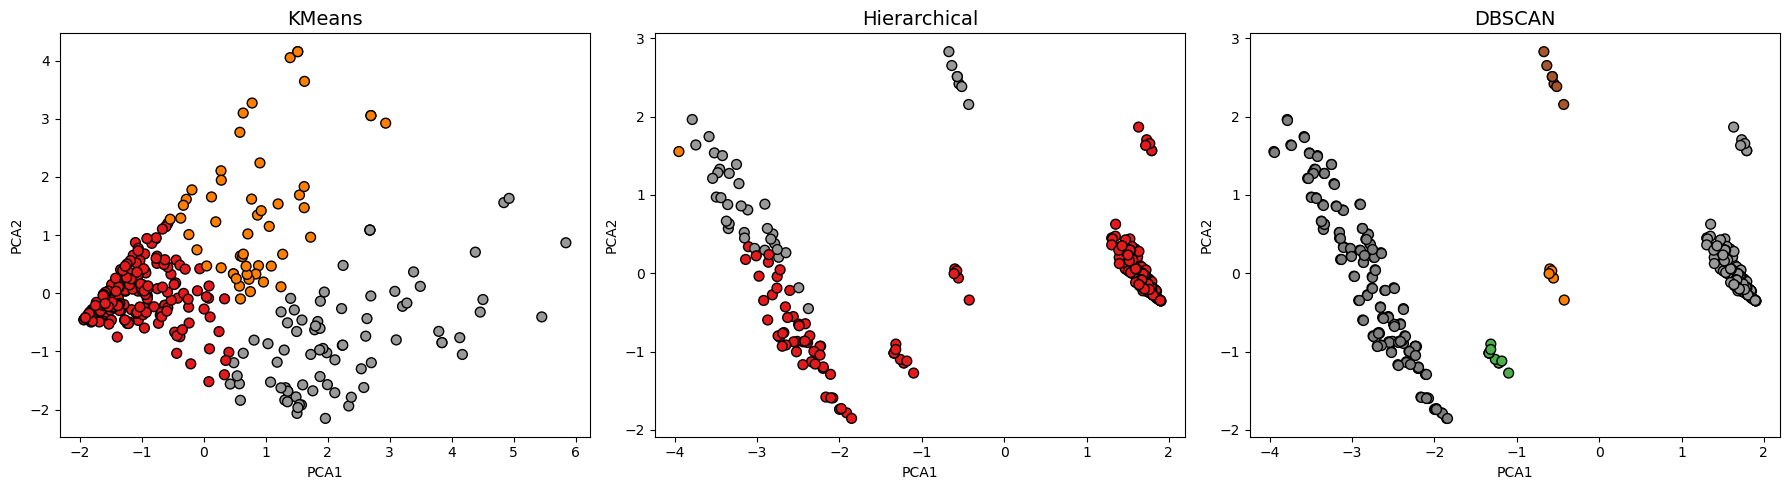

In [66]:
import matplotlib.pyplot as plt
import matplotlib
from sklearn.decomposition import PCA
import numpy as np

# --- PCA results ---
pca_kmeans_result = PCA(n_components=2).fit_transform(scaled_df)
pca_hier_result = PCA(n_components=2).fit_transform(scaled_df_clean)
pca_dbscan_result = PCA(n_components=2).fit_transform(scaled_df_clean)

# --- Correct label arrays ---
labels_kmeans = features["Cluster"].values        # Use 'features' for KMeans
labels_hier = hierarchical_clustered["Cluster"].values   # make sure this exists
labels_dbscan = nutrients_clean["Cluster"].values        # make sure this exists

# --- Prepare datasets dict ---
datasets_to_plot = {
    "KMeans": (pca_kmeans_result, labels_kmeans),
    "Hierarchical": (pca_hier_result, labels_hier),
    "DBSCAN": (pca_dbscan_result, labels_dbscan)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (X_plot, labels_array)) in zip(axes, datasets_to_plot.items()):
    if name == "DBSCAN":
        # Handle noise (-1) separately
        unique_labels = sorted(set(labels_array))
        cluster_ids = [c for c in unique_labels if c != -1]
        cmap = matplotlib.colormaps['Set1'].resampled(len(cluster_ids))
        
        colors_numeric = np.array([cluster_ids.index(c) if c != -1 else -1 for c in labels_array])
        
        sc = ax.scatter(
            X_plot[:, 0], X_plot[:, 1],
            c=colors_numeric,
            cmap=cmap,
            s=50,
            edgecolors='k'
        )
        
        noise_mask = labels_array == -1
        ax.scatter(
            X_plot[noise_mask, 0], X_plot[noise_mask, 1],
            c='grey', s=50, edgecolors='k', label='Noise'
        )
    else:
        sc = ax.scatter(X_plot[:, 0], X_plot[:, 1], c=labels_array, cmap='Set1', s=50, edgecolors='k')

    ax.set_title(name, fontsize=14)
    ax.set_xlabel('PCA1')
    ax.set_ylabel('PCA2')

plt.tight_layout()
plt.show()

This cell visualizes the clustering results of KMeans, Hierarchical, and DBSCAN on the first two principal components (PCA1 and PCA2) of the nutritional data.  

- **KMeans**: Shows clusters for all data points, including any outliers.  
- **Hierarchical**: Uses the cleaned dataset without outliers to show more refined clusters.  
- **DBSCAN**: Includes all points, with noise points (labeled `-1`) displayed in grey to highlight points that do not belong to any cluster.  

The scatter plots provide a visual comparison of cluster separation and cohesion across different algorithms, helping to understand the clustering structure in the reduced 2D space.

# 6.0 Prototype

### DBSCAN Clustering Conclusion

After comparing the three clustering algorithms (KMeans, Hierarchical, DBSCAN) on our dataset, we can conclude the following about DBSCAN:

- **Outlier Handling:**  
  DBSCAN explicitly identifies noise points (labeled `-1`), giving a more realistic representation of cluster structure compared to KMeans, which forces all points into clusters.

- **Cluster Shape:**  
  Capable of detecting arbitrarily shaped clusters and dense regions effectively, unlike KMeans which assumes spherical clusters.

- **Performance Metrics:**  
  - Silhouette Score: Slightly lower than KMeans in some runs, but this is because noise points are excluded.  
  - Calinski-Harabasz Score: Lower than KMeans, reflecting that some points are excluded as noise.  
  - Davies-Bouldin Score: Lowest among the algorithms, indicating better cluster separation and compactness when ignoring noise.

**✅ Overall Conclusion:**  
DBSCAN is preferred for this dataset because it robustly handles outliers, captures natural cluster shapes, and provides a more meaningful interpretation of the data, despite slightly lower Silhouette or CH scores.


### 🔄 Data Preprocessing Recap

Before building the clustering prototype, the dataset was preprocessed to ensure reliable and interpretable clustering results:

1. **Data Cleaning**  
   - Removed irrelevant columns and handled missing values.  
   - Checked for inconsistencies and corrected data types.

2. **Outlier Handling**  
   - For **Hierarchical Clustering** and **DBSCAN**: removed outliers using the IQR method to improve cluster quality.

3. **Scaling / Normalization**  
   - Standardized numeric features to ensure each nutrient contributed equally to distance calculations.

4. **Dimensionality Reduction (PCA)**  
   - Reduced the dataset to 2 principal components for visualization purposes.  
   - Preserved most variance to represent cluster structures accurately.

5. **Prepared Datasets for Each Algorithm**  
   - **KMeans**: scaled data including outliers for prediction purposes.  
   - **Hierarchical**: cleaned and scaled data (outliers removed) for tighter clusters.  
   - **DBSCAN**: cleaned and scaled data (outliers removed) for accurate cluster detection.

> ✅ With preprocessing complete, the dataset is ready for the clustering prototype using **KMeans** for predictive clustering and **DBSCAN** for visualizing cluster structure.

### 🧩 Role of Clustering Algorithms in the Prototype

In the clustering prototype, both **KMeans** and **DBSCAN** play complementary roles, serving different purposes in the workflow:

---

#### **1. KMeans: Predictive Clustering**
- **Purpose:** Assign new food items to clusters for **prediction**.  
- **Why KMeans:**  
  - KMeans creates **centroid-based clusters**, which makes it easy to classify new data points by calculating their distance to existing centroids.  
  - Efficient for larger datasets and consistent cluster assignments.  
- **How it is used in the prototype:**  
  1. Fit KMeans on the scaled dataset (including outliers).  
  2. Store the cluster centroids for reference.  
  3. Predict cluster labels for new food items based on the nearest centroid.  
- **Role in prototype:** Provides **automated cluster assignment** for unseen data, enabling the predictive function of the system.

---

#### **2. DBSCAN: Visualization and Cluster Profiling**
- **Purpose:** Identify **natural clusters** in the dataset and detect the structure for **visual analysis**.  
- **Why DBSCAN:**  
  - Density-based clustering captures clusters of **arbitrary shapes**.  
  - Automatically detects sparse regions, improving cluster visualization quality.  
- **How it is used in the prototype:**  
  1. Fit DBSCAN on the cleaned and scaled dataset.  
  2. Assign cluster labels to points (noise or main clusters).  
  3. Generate cluster profiles (average nutrient values) and visualize clusters via **PCA scatter plots** or **radar charts**.  
- **Role in prototype:** Provides **insight into cluster composition**, supporting interpretation and validation of clustering results.

---

> ✅ **Summary:**  
> - **KMeans** → Used for **predicting cluster membership** of new data points.  
> - **DBSCAN** → Used for **exploring and visualizing cluster structures**, especially for evaluating density and natural groupings.  
> Together, they ensure the prototype is both **predictive and interpretable**.

### 6.1 Launching the Prototype Web Application


In [67]:
from app import run_flask_with_browser

run_flask_with_browser()


--- KMeans Debug Info --- {'training_counts': {2: 200, 0: 79, 1: 53}, 'cluster_labels': {2: 'Protein-Fiber Rich (Cluster 2)', 0: 'Balanced Nutrition (Cluster 0)', 1: 'High-Energy Dense (Cluster 1)'}, 'centroids': [[301.76231000712124, 19.427253198766493, 19.52755608096964, 1.876333222526525, 18.99755025826497], [324.5285671056908, 5.886792452830188, 5.69811320754717, 0.9905660377358492, 63.28015907434295], [89.43000000000004, 2.610000000000001, 2.1499999999999932, 0.7935499999999998, 15.043999999999999]]}

--- KMeans Debug Info --- {'training_counts': {2: 109, 1: 80, 0: 71}, 'cluster_labels': {2: 'Protein-Fiber Rich (Cluster 2)', 0: 'Balanced Nutrition (Cluster 0)', 1: 'High-Energy Dense (Cluster 1)'}, 'centroids': [[98.67605633802819, 2.4013042483276164, 0.8468785220827155, 1.181816063677176, 21.615334390644694], [214.87127451545615, 10.796776084819376, 10.063639850961465, 0.19861866421309576, 14.628749999999993], [88.79816513761467, 1.6788990825688046, 2.128440366972479, 0.155137614

 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [16/May/2026 18:07:08] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:08] "GET /static/style.css HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:08] "GET /static/plot.js HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:09] "GET /data HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:09] "GET /summary HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:09] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [16/May/2026 18:07:23] "POST /recluster HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:23] "GET /data HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:23] "GET /summary HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:27] "POST /recluster HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:27] "GET /data HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:27] "GET /summary HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:29] "POST /recluster HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 18:07:29] "GET /data HTTP/1.1" 2


The following cell runs the Flask server and automatically opens the web interface in your default browser.  

- **Function:** `run_flask_with_browser()`  
- **Purpose:** Start the prototype application, allowing users to interact with the clustering system through a **user-friendly web interface**.  
- **Notes:**  
  - Ensure all dependencies are installed and the current working directory contains the `app.py` file.  
  - The web interface provides access to cluster predictions, visualizations, and nutrient profiling for new or existing food items.

### 🔎 Interactive Actions on the PCA Plot  

When you open the **interactive PCA clustering plot** in the browser (via Flask + Plotly), you can perform the following actions:

---

#### 🔍 Navigation & Viewing  
1. **Zoom** (magnifying glass icon)  
   - Click and drag over a region to zoom in.  
   - Double-click resets to full view.  

2. **Pan** (hand icon)  
   - Click and drag to move the view without zooming.  

3. **Box Select / Lasso Select**  
   - Box select: Draw a rectangle to highlight points.  
   - Lasso select: Draw a freeform shape around points.  

---

#### 🎨 Data Interaction  
4. **Hover Info**  
   - Hover over a point to see:  
     - *Food Name*  
     - *Category*  
     - *Cluster ID*  

5. **Legend Toggle**  
   - Click on a legend item (cluster or noise) to show/hide it.  
   - Double-click a legend item to isolate only that group.  

6. **Color Encoding**  
   - Each point is colored by **Cluster ID**.  
   - Noise points (`Cluster = -1`) appear **gray**.  

---

#### 📷 Exporting & Saving  
7. **Download as PNG (camera icon)**  
   - Export the current view (zoom/filters applied) as an image.  
   - Useful for reports and documentation.  

---

#### 🧭 Reset View  
8. **Home (reset axis icon)**  
   - Resets zoom/pan back to the default full PCA view.  

---

✅ **Summary:**  
- **Zoom, pan, reset** → navigation.  
- **Box/lasso select & hover** → explore data points.  
- **Legend toggle & colors** → filter clusters vs. noise.  
- **Camera export** → save plots for reports.